In [1]:
import os
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")

In [23]:
from pathlib import Path

CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MODEL_NAME = "resnet18"          # use resnet18 now
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 3e-4             # lower LR for pretrained model
WEIGHT_DECAY = 1e-4
PATIENCE = 8
NUM_WORKERS = 0                  # IMPORTANT for Windows/WSL Jupyter
IMAGE_SIZE = 224
USE_PRETRAINED = True
USE_WEIGHTED_LOSS = True

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("Exists      :", SPLIT_CSV.exists())

BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_42.csv
Exists      : True


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [4]:
split_df = pd.read_csv(SPLIT_CSV)

print(split_df.shape)
display(split_df.head())

print(split_df["split"].value_counts())
print(split_df.groupby("split")["class_id"].nunique())

(2312, 14)


,dataset,filepath,relative_path,filename,class_id,class_name,width,height,mode,file_size_bytes,md5,read_error,split,seed
0,GC10,/mnt/e/CVPR/GC10/6/img_05_4406743300_00516.jpg,6/img_05_4406743300_00516.jpg,img_05_4406743300_00516.jpg,6,class_6,2048,1000,L,417074,15278af3890244410b468f9d0f18843c,NaN,train,42
1,GC10,/mnt/e/CVPR/GC10/4/img_03_424798500_00466.jpg,4/img_03_424798500_00466.jpg,img_03_424798500_00466.jpg,4,class_4,2048,1000,L,336170,4559975600be63ab9d342532102e6772,NaN,train,42
2,GC10,/mnt/e/CVPR/GC10/5/img_04_425503600_00019.jpg,5/img_04_425503600_00019.jpg,img_04_425503600_00019.jpg,5,class_5,2048,1000,L,389149,fe62220be3d57b4a3977d1cdc56f014b,NaN,train,42
3,GC10,/mnt/e/CVPR/GC10/6/img_06_3436814300_00056.jpg,6/img_06_3436814300_00056.jpg,img_06_3436814300_00056.jpg,6,class_6,2048,1000,L,450002,0a0264c5e0d27aa71b83ae0cb56b55e9,NaN,train,42
4,GC10,/mnt/e/CVPR/GC10/6/img_08_4406743300_00470.jpg,6/img_08_4406743300_00470.jpg,img_08_4406743300_00470.jpg,6,class_6,2048,1000,L,382174,845a8cf42a9612dc6b6d028511373132,NaN,train,42


split
train    1618
val       347
test      347
Name: count, dtype: int64
split
test     10
train    10
val      10
Name: class_id, dtype: int64


In [5]:
def normalize_path(path_str):
    path_str = str(path_str)

    # Already valid
    p = Path(path_str)
    if p.exists():
        return str(p)

    # Windows E:\... -> /mnt/e/...
    if len(path_str) >= 3 and path_str[1:3] == ":\\":
        drive = path_str[0].lower()
        rest = path_str[3:].replace("\\", "/")
        wsl_path = f"/mnt/{drive}/{rest}"
        if Path(wsl_path).exists():
            return wsl_path

    # /mnt/e/... -> E:\...
    if path_str.startswith("/mnt/") and len(path_str) > 6:
        drive = path_str[5]
        rest = path_str[7:].replace("/", "\\")
        win_path = f"{drive.upper()}:\\{rest}"
        if Path(win_path).exists():
            return win_path

    return path_str

split_df["filepath"] = split_df["filepath"].apply(normalize_path)

# quick check
for i in range(3):
    print(split_df.iloc[i]["filepath"], "->", Path(split_df.iloc[i]["filepath"]).exists())

/mnt/e/CVPR/GC10/6/img_05_4406743300_00516.jpg -> True
/mnt/e/CVPR/GC10/4/img_03_424798500_00466.jpg -> True
/mnt/e/CVPR/GC10/5/img_04_425503600_00019.jpg -> True


In [6]:
train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df  = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (1618, 14)
Val  : (347, 14)
Test : (347, 14)


In [7]:
basic_transform_for_stats = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

class TempImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        img = self.transform(img)
        return img

temp_ds = TempImageDataset(train_df, basic_transform_for_stats)
temp_loader = DataLoader(temp_ds, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in tqdm(temp_loader, desc="Computing mean/std"):
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
    num_pixels += images.size(0) * images.size(2) * images.size(3)

train_mean = channel_sum / num_pixels
train_std = torch.sqrt(channel_sq_sum / num_pixels - train_mean ** 2)

print("Train mean:", train_mean.tolist())
print("Train std :", train_std.tolist())

Computing mean/std:   0%|          | 0/51 [00:00<?, ?it/s]

Train mean: [0.3359968066215515, 0.3359968066215515, 0.3359968066215515]
Train std : [0.1534603238105774, 0.1534603238105774, 0.1534603238105774]


In [24]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

In [9]:
class GC10Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = int(row["class_id"]) - 1   # convert 1..10 -> 0..9

        img = Image.open(img_path).convert("L")
        img = self.transform(img)

        return img, label, img_path

In [10]:
train_ds = GC10Dataset(train_df, train_transform)
val_ds   = GC10Dataset(val_df, eval_transform)
test_ds  = GC10Dataset(test_df, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 51
Val batches  : 11
Test batches : 11


In [25]:
class CustomCNNBase(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CustomCNNBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CustomCNNDrop(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_model(model_name, num_classes=10, use_pretrained=True):
    if model_name == "customcnn_base":
        return CustomCNNBase(num_classes=num_classes)

    elif model_name == "customcnn_bn":
        return CustomCNNBN(num_classes=num_classes)

    elif model_name == "customcnn_drop":
        return CustomCNNDrop(num_classes=num_classes)

    elif model_name == "resnet18":
        if use_pretrained:
            weights = models.ResNet18_Weights.IMAGENET1K_V1
        else:
            weights = None
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    elif model_name == "mobilenetv3_small":
        if use_pretrained:
            weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        else:
            weights = None
        model = models.mobilenet_v3_small(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model

    else:
        raise ValueError(f"Unknown model: {model_name}")

In [26]:
model = build_model(MODEL_NAME, num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)

# class weights from TRAIN split only
train_class_counts = train_df["class_id"].value_counts().sort_index()
print("Train class counts:")
print(train_class_counts)

class_weights = []
total_train = len(train_df)

for class_id in range(1, NUM_CLASSES + 1):
    count = train_class_counts[class_id]
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights)

if USE_WEIGHTED_LOSS:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

if OPTIMIZER_NAME == "adamw":
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER_NAME == "sgd":
    optimizer = optim.SGD(
        model.parameters(),
        lr=1e-2,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
        nesterov=True
    )
else:
    raise ValueError("Unsupported optimizer")

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model.__class__.__name__)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/vector1/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:03<00:00, 12.6MB/s]


Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64
Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')
ResNet


In [13]:
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)
    return epoch_loss, metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []
    all_paths = []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_logits.extend(outputs.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)

    pred_df = pd.DataFrame({
        "filepath": all_paths,
        "y_true": all_labels,
        "y_pred": all_preds,
    })

    probs_np = np.array(all_probs)
    logits_np = np.array(all_logits)

    for c in range(probs_np.shape[1]):
        pred_df[f"prob_class_{c}"] = probs_np[:, c]
        pred_df[f"logit_class_{c}"] = logits_np[:, c]

    return epoch_loss, metrics, pred_df

In [27]:
run_name = f"{MODEL_NAME}__{OPTIMIZER_NAME}__weightedCE__pretrained_{USE_PRETRAINED}__seed_{SEED}"
RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "image_size": IMAGE_SIZE,
    "split_csv": str(SPLIT_CSV),
    "train_mean": train_mean.tolist(),
    "train_std": train_std.tolist(),
    "use_pretrained": USE_PRETRAINED,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
}

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("RUN_DIR:", RUN_DIR)

RUN_DIR: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE__pretrained_True__seed_42


In [39]:
history = []
best_val_f1 = -1.0
best_epoch = -1
best_val_df = None
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_metrics, val_pred_df = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        best_val_df = val_pred_df.copy()
        epochs_without_improvement = 0

        torch.save(model.state_dict(), RUN_DIR / "best_model.pth")
        best_val_df.to_csv(RUN_DIR / "val_predictions.csv", index=False)

        print("Best model updated.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "train_log.csv", index=False)

print("\nBest epoch:", best_epoch)
print("Best val macro-F1:", best_val_f1)


Epoch 1/30


Train:   0%|          | 0/51 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

train_loss=2.0195 | val_loss=1.6974 | train_macro_f1=0.3225 | val_macro_f1=0.3798
Best model updated.

Epoch 2/30


Train:   0%|          | 0/51 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

train_loss=0.5552 | val_loss=1.3105 | train_macro_f1=0.9759 | val_macro_f1=0.6668

Epoch 30/30


Train:   0%|          | 0/51 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

train_loss=0.5564 | val_loss=1.3171 | train_macro_f1=0.9735 | val_macro_f1=0.6692

Best epoch: 27
Best val macro-F1: 0.68454099324587


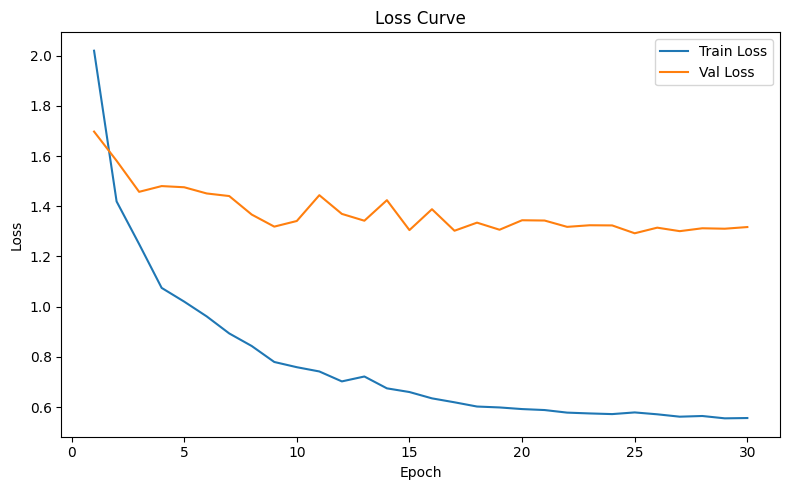

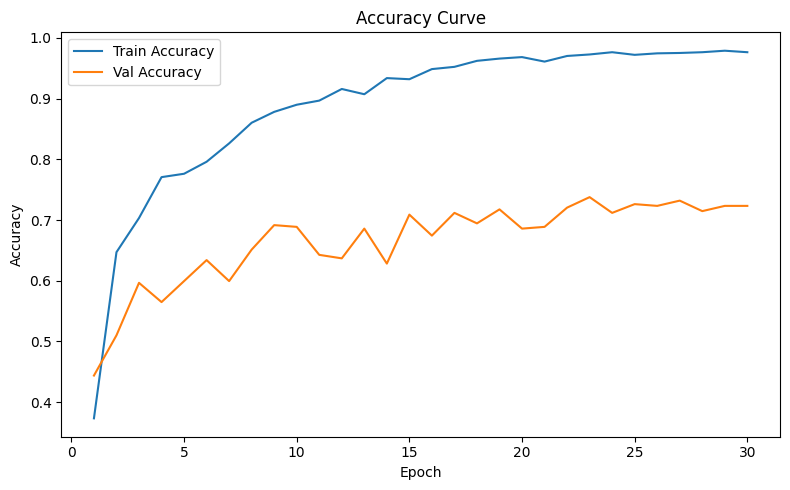

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

In [41]:
best_model = build_model(MODEL_NAME, num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load(RUN_DIR / "best_model.pth", map_location=DEVICE))

test_loss, test_metrics, test_pred_df = evaluate(best_model, test_loader, criterion, DEVICE)

print("Test loss:", round(test_loss, 4))
print(json.dumps(test_metrics, indent=2))

test_pred_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Test loss: 1.3408
{
  "accuracy": 0.7463976945244957,
  "macro_precision": 0.6695138617161571,
  "macro_recall": 0.6622000121143699,
  "macro_f1": 0.6450670214221337,
  "weighted_precision": 0.781597289697257,
  "weighted_recall": 0.7463976945244957,
  "weighted_f1": 0.7435854619852745
}


In [42]:
with open(RUN_DIR / "metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
            "test_loss": float(test_loss),
            **{k: float(v) for k, v in test_metrics.items()}
        },
        f,
        indent=2
    )

print("Saved metrics_test.json")

Saved metrics_test.json


In [43]:
y_true = test_pred_df["y_true"].values
y_pred = test_pred_df["y_pred"].values

report = classification_report(y_true, y_pred, digits=4, zero_division=0)
print(report)

              precision    recall  f1-score   support

           0     0.8182    0.2727    0.4091        33
           1     0.6667    0.8293    0.7391        41
           2     0.9118    0.9118    0.9118        34
           3     0.8889    0.7442    0.8101        43
           4     0.6341    0.8667    0.7324        30
           5     0.9412    0.8163    0.8743        98
           6     0.4510    0.6970    0.5476        33
           7     0.2500    0.2000    0.2222         5
           8     0.3333    0.3750    0.3529         8
           9     0.8000    0.9091    0.8511        22

    accuracy                         0.7464       347
   macro avg     0.6695    0.6622    0.6451       347
weighted avg     0.7816    0.7464    0.7436       347



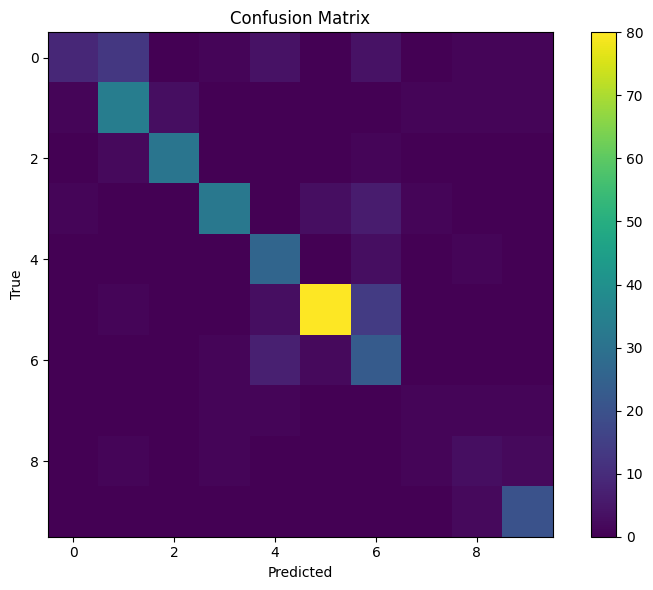

In [44]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

In [45]:
summary_row = {
    "run_name": run_name,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "test_loss": test_loss,
    **test_metrics
}

summary_df = pd.DataFrame([summary_row])
display(summary_df)

summary_csv = RUN_DIR / "run_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)
print("All outputs saved in:", RUN_DIR)

,run_name,seed,model_name,optimizer_name,best_epoch,best_val_macro_f1,test_loss,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,resnet18__adamw__weightedCE_True__labelsmooth_...,42,resnet18,adamw,27,0.684541,1.340839,0.746398,0.669514,0.6622,0.645067,0.781597,0.746398,0.743585


Saved: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/run_summary.csv
All outputs saved in: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42


In [35]:
from pathlib import Path

CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MODEL_NAME = "resnet18"
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 8
NUM_WORKERS = 0
IMAGE_SIZE = 224

USE_PRETRAINED = True
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
LABEL_SMOOTHING = 0.05

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("Exists      :", SPLIT_CSV.exists())

BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_42.csv
Exists      : True


In [36]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

In [37]:
model = build_model(MODEL_NAME, num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)

train_class_counts = train_df["class_id"].value_counts().sort_index()
print("Train class counts:")
print(train_class_counts)

class_weights = []
total_train = len(train_df)

for class_id in range(1, NUM_CLASSES + 1):
    count = train_class_counts[class_id]
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights)

if USE_WEIGHTED_LOSS and USE_LABEL_SMOOTHING:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING
    )
elif USE_WEIGHTED_LOSS:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

if OPTIMIZER_NAME == "adamw":
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER_NAME == "sgd":
    optimizer = optim.SGD(
        model.parameters(),
        lr=1e-2,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
        nesterov=True
    )
else:
    raise ValueError("Unsupported optimizer")

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model.__class__.__name__)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64
Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')
ResNet


In [38]:
run_name = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)
RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "image_size": IMAGE_SIZE,
    "split_csv": str(SPLIT_CSV),
    "train_mean": train_mean.tolist(),
    "train_std": train_std.tolist(),
    "use_pretrained": USE_PRETRAINED,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_label_smoothing": USE_LABEL_SMOOTHING,
    "label_smoothing": LABEL_SMOOTHING,
}

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("RUN_DIR:", RUN_DIR)

RUN_DIR: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42


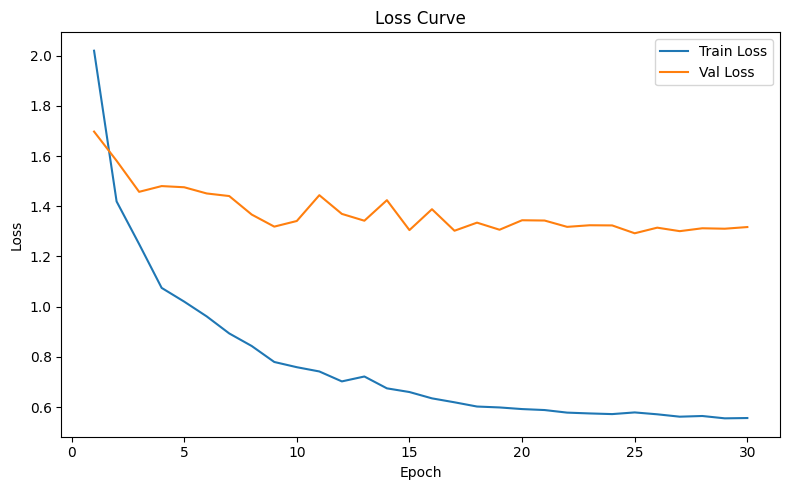

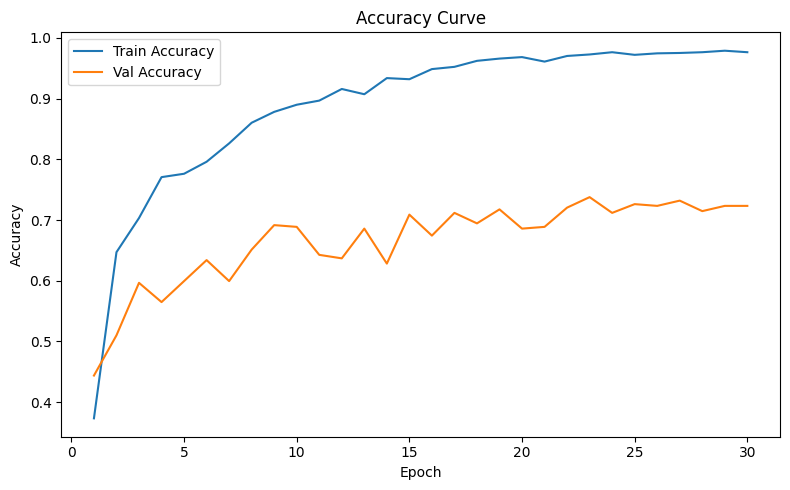

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

In [47]:
best_model = build_model(MODEL_NAME, num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load(RUN_DIR / "best_model.pth", map_location=DEVICE))

test_loss, test_metrics, test_pred_df = evaluate(best_model, test_loader, criterion, DEVICE)

print("Test loss:", round(test_loss, 4))
print(json.dumps(test_metrics, indent=2))

test_pred_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Test loss: 1.3408
{
  "accuracy": 0.7463976945244957,
  "macro_precision": 0.6695138617161571,
  "macro_recall": 0.6622000121143699,
  "macro_f1": 0.6450670214221337,
  "weighted_precision": 0.781597289697257,
  "weighted_recall": 0.7463976945244957,
  "weighted_f1": 0.7435854619852745
}


In [48]:
with open(RUN_DIR / "metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
            "test_loss": float(test_loss),
            **{k: float(v) for k, v in test_metrics.items()}
        },
        f,
        indent=2
    )

print("Saved metrics_test.json")

Saved metrics_test.json


In [49]:
y_true = test_pred_df["y_true"].values
y_pred = test_pred_df["y_pred"].values

report = classification_report(y_true, y_pred, digits=4, zero_division=0)
print(report)

              precision    recall  f1-score   support

           0     0.8182    0.2727    0.4091        33
           1     0.6667    0.8293    0.7391        41
           2     0.9118    0.9118    0.9118        34
           3     0.8889    0.7442    0.8101        43
           4     0.6341    0.8667    0.7324        30
           5     0.9412    0.8163    0.8743        98
           6     0.4510    0.6970    0.5476        33
           7     0.2500    0.2000    0.2222         5
           8     0.3333    0.3750    0.3529         8
           9     0.8000    0.9091    0.8511        22

    accuracy                         0.7464       347
   macro avg     0.6695    0.6622    0.6451       347
weighted avg     0.7816    0.7464    0.7436       347



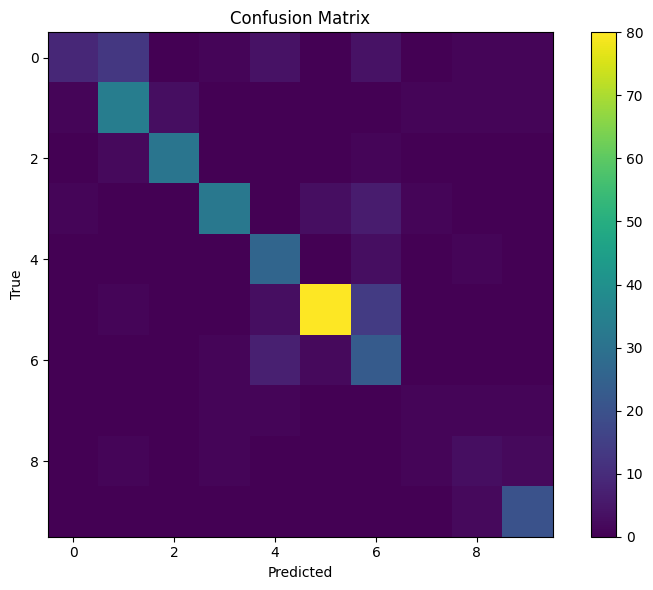

In [50]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

In [51]:
summary_row = {
    "run_name": run_name,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "test_loss": test_loss,
    **test_metrics
}

summary_df = pd.DataFrame([summary_row])
display(summary_df)

summary_csv = RUN_DIR / "run_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)
print("All outputs saved in:", RUN_DIR)

,run_name,seed,model_name,optimizer_name,best_epoch,best_val_macro_f1,test_loss,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,resnet18__adamw__weightedCE_True__labelsmooth_...,42,resnet18,adamw,27,0.684541,1.340839,0.746398,0.669514,0.6622,0.645067,0.781597,0.746398,0.743585


Saved: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/run_summary.csv
All outputs saved in: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42


In [1]:
import os
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
from pathlib import Path

# Auto-detect Windows / WSL path
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# -------- EXPERIMENT CONFIG --------
SEED = 42
MODEL_NAME = "mobilenetv3_small"
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 8
NUM_WORKERS = 0
IMAGE_SIZE = 224

USE_PRETRAINED = True
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
LABEL_SMOOTHING = 0.05

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("Exists      :", SPLIT_CSV.exists())

BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_42.csv
Exists      : True


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [4]:
split_df = pd.read_csv(SPLIT_CSV)

print("Split dataframe shape:", split_df.shape)
display(split_df.head())

print("\nSplit counts:")
print(split_df["split"].value_counts())

print("\nUnique classes per split:")
print(split_df.groupby("split")["class_id"].nunique())

Split dataframe shape: (2312, 14)


,dataset,filepath,relative_path,filename,class_id,class_name,width,height,mode,file_size_bytes,md5,read_error,split,seed
0,GC10,/mnt/e/CVPR/GC10/6/img_05_4406743300_00516.jpg,6/img_05_4406743300_00516.jpg,img_05_4406743300_00516.jpg,6,class_6,2048,1000,L,417074,15278af3890244410b468f9d0f18843c,NaN,train,42
1,GC10,/mnt/e/CVPR/GC10/4/img_03_424798500_00466.jpg,4/img_03_424798500_00466.jpg,img_03_424798500_00466.jpg,4,class_4,2048,1000,L,336170,4559975600be63ab9d342532102e6772,NaN,train,42
2,GC10,/mnt/e/CVPR/GC10/5/img_04_425503600_00019.jpg,5/img_04_425503600_00019.jpg,img_04_425503600_00019.jpg,5,class_5,2048,1000,L,389149,fe62220be3d57b4a3977d1cdc56f014b,NaN,train,42
3,GC10,/mnt/e/CVPR/GC10/6/img_06_3436814300_00056.jpg,6/img_06_3436814300_00056.jpg,img_06_3436814300_00056.jpg,6,class_6,2048,1000,L,450002,0a0264c5e0d27aa71b83ae0cb56b55e9,NaN,train,42
4,GC10,/mnt/e/CVPR/GC10/6/img_08_4406743300_00470.jpg,6/img_08_4406743300_00470.jpg,img_08_4406743300_00470.jpg,6,class_6,2048,1000,L,382174,845a8cf42a9612dc6b6d028511373132,NaN,train,42



Split counts:
split
train    1618
val       347
test      347
Name: count, dtype: int64

Unique classes per split:
split
test     10
train    10
val      10
Name: class_id, dtype: int64


In [5]:
def normalize_path(path_str):
    path_str = str(path_str)

    p = Path(path_str)
    if p.exists():
        return str(p)

    # Windows path -> WSL path
    if len(path_str) >= 3 and path_str[1:3] == ":\\":
        drive = path_str[0].lower()
        rest = path_str[3:].replace("\\", "/")
        wsl_path = f"/mnt/{drive}/{rest}"
        if Path(wsl_path).exists():
            return wsl_path

    # WSL path -> Windows path
    if path_str.startswith("/mnt/") and len(path_str) > 7:
        drive = path_str[5]
        rest = path_str[7:].replace("/", "\\")
        win_path = f"{drive.upper()}:\\{rest}"
        if Path(win_path).exists():
            return win_path

    return path_str

split_df["filepath"] = split_df["filepath"].apply(normalize_path)

print("Path existence check:")
for i in range(5):
    p = split_df.iloc[i]["filepath"]
    print(p, "->", Path(p).exists())

Path existence check:
/mnt/e/CVPR/GC10/6/img_05_4406743300_00516.jpg -> True
/mnt/e/CVPR/GC10/4/img_03_424798500_00466.jpg -> True
/mnt/e/CVPR/GC10/5/img_04_425503600_00019.jpg -> True
/mnt/e/CVPR/GC10/6/img_06_3436814300_00056.jpg -> True
/mnt/e/CVPR/GC10/6/img_08_4406743300_00470.jpg -> True


In [6]:
train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df  = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain class counts:")
print(train_df["class_id"].value_counts().sort_index())

Train: (1618, 14)
Val  : (347, 14)
Test : (347, 14)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64


In [7]:
basic_transform_for_stats = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

class TempImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        img = self.transform(img)
        return img

temp_ds = TempImageDataset(train_df, basic_transform_for_stats)
temp_loader = DataLoader(
    temp_ds,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in tqdm(temp_loader, desc="Computing mean/std"):
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
    num_pixels += images.size(0) * images.size(2) * images.size(3)

train_mean = channel_sum / num_pixels
train_std = torch.sqrt(channel_sq_sum / num_pixels - train_mean ** 2)

print("Train mean:", train_mean.tolist())
print("Train std :", train_std.tolist())

Computing mean/std:   0%|          | 0/51 [00:00<?, ?it/s]

Train mean: [0.3359968066215515, 0.3359968066215515, 0.3359968066215515]
Train std : [0.1534603238105774, 0.1534603238105774, 0.1534603238105774]


In [8]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

print("Transforms ready.")

Transforms ready.


In [9]:
class GC10Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = int(row["class_id"]) - 1  # convert 1..10 -> 0..9

        img = Image.open(img_path).convert("L")
        img = self.transform(img)

        return img, label, img_path

In [10]:
train_ds = GC10Dataset(train_df, train_transform)
val_ds   = GC10Dataset(val_df, eval_transform)
test_ds  = GC10Dataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 51
Val batches  : 11
Test batches : 11


In [11]:
def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        # fallback for older torchvision versions
        model = models.mobilenet_v3_small(pretrained=use_pretrained)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)
print(model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [12]:
train_class_counts = train_df["class_id"].value_counts().sort_index()
print("Train class counts:")
print(train_class_counts)

class_weights = []
total_train = len(train_df)

for class_id in range(1, NUM_CLASSES + 1):
    count = int(train_class_counts[class_id])
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights)

if USE_WEIGHTED_LOSS and USE_LABEL_SMOOTHING:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING
    )
elif USE_WEIGHTED_LOSS:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

if OPTIMIZER_NAME == "adamw":
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER_NAME == "sgd":
    optimizer = optim.SGD(
        model.parameters(),
        lr=1e-2,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
        nesterov=True
    )
else:
    raise ValueError("Unsupported optimizer")

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("Criterion:", criterion)
print("Optimizer:", optimizer)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64
Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')
Criterion: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)


In [13]:
train_class_counts = train_df["class_id"].value_counts().sort_index()
print("Train class counts:")
print(train_class_counts)

class_weights = []
total_train = len(train_df)

for class_id in range(1, NUM_CLASSES + 1):
    count = int(train_class_counts[class_id])
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights)

if USE_WEIGHTED_LOSS and USE_LABEL_SMOOTHING:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING
    )
elif USE_WEIGHTED_LOSS:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

if OPTIMIZER_NAME == "adamw":
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER_NAME == "sgd":
    optimizer = optim.SGD(
        model.parameters(),
        lr=1e-2,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
        nesterov=True
    )
else:
    raise ValueError("Unsupported optimizer")

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("Criterion:", criterion)
print("Optimizer:", optimizer)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64
Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')
Criterion: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)


In [14]:
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)
    return epoch_loss, metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []
    all_paths = []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_logits.extend(outputs.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)

    pred_df = pd.DataFrame({
        "filepath": all_paths,
        "y_true": all_labels,
        "y_pred": all_preds,
    })

    probs_np = np.array(all_probs)
    logits_np = np.array(all_logits)

    for c in range(probs_np.shape[1]):
        pred_df[f"prob_class_{c}"] = probs_np[:, c]
        pred_df[f"logit_class_{c}"] = logits_np[:, c]

    return epoch_loss, metrics, pred_df

In [16]:
run_name = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "image_size": IMAGE_SIZE,
    "num_workers": NUM_WORKERS,
    "split_csv": str(SPLIT_CSV),
    "train_mean": train_mean.tolist(),
    "train_std": train_std.tolist(),
    "use_pretrained": USE_PRETRAINED,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_label_smoothing": USE_LABEL_SMOOTHING,
    "label_smoothing": LABEL_SMOOTHING,
}

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("RUN_DIR:", RUN_DIR)

RUN_DIR: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42


In [17]:
history = []
best_val_f1 = -1.0
best_epoch = -1
best_val_df = None
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_metrics, val_pred_df = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        best_val_df = val_pred_df.copy()
        epochs_without_improvement = 0

        torch.save(model.state_dict(), RUN_DIR / "best_model.pth")
        best_val_df.to_csv(RUN_DIR / "val_predictions.csv", index=False)

        print("Best model updated.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "train_log.csv", index=False)

print("\nBest epoch:", best_epoch)
print("Best val macro-F1:", best_val_f1)


Epoch 1/30


Train:   0%|          | 0/51 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

train_loss=2.2082 | val_loss=2.2807 | train_macro_f1=0.2580 | val_macro_f1=0.2133
Best model updated.

Epoch 2/30


Train:   0%|          | 0/51 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

train_loss=0.6129 | val_loss=0.9928 | train_macro_f1=0.9541 | val_macro_f1=0.7730

Epoch 21/30


Train:   0%|          | 0/51 [00:00<?, ?it/s]

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

train_loss=0.6106 | val_loss=0.9980 | train_macro_f1=0.9620 | val_macro_f1=0.7619
Early stopping triggered at epoch 21.

Best epoch: 13
Best val macro-F1: 0.7855660488337639


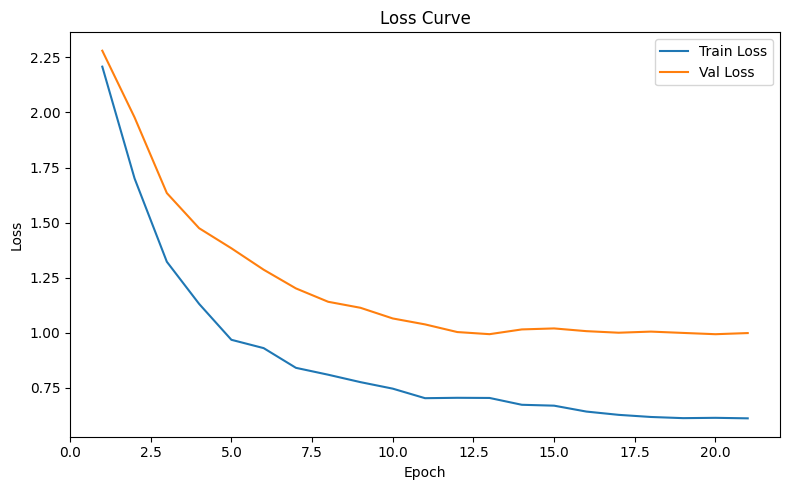

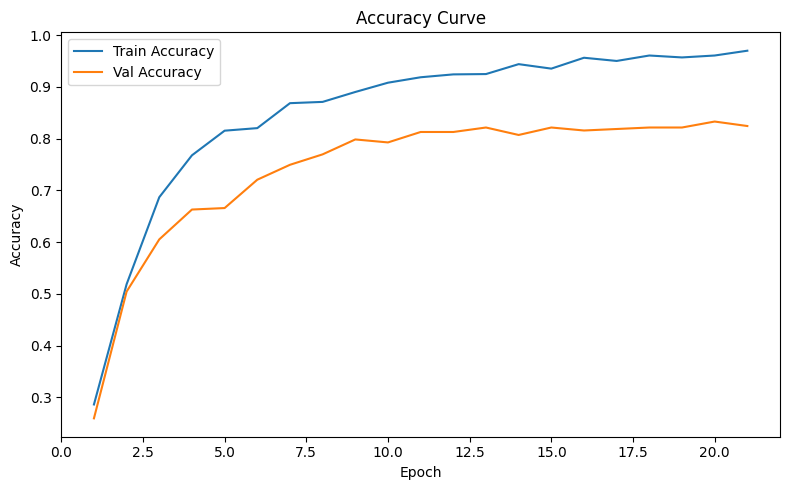

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

In [19]:
best_model = build_mobilenetv3_small(
    num_classes=NUM_CLASSES,
    use_pretrained=USE_PRETRAINED
).to(DEVICE)

best_model.load_state_dict(torch.load(RUN_DIR / "best_model.pth", map_location=DEVICE))

test_loss, test_metrics, test_pred_df = evaluate(best_model, test_loader, criterion, DEVICE)

print("Test loss:", round(test_loss, 4))
print(json.dumps(test_metrics, indent=2))

test_pred_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

Eval:   0%|          | 0/11 [00:00<?, ?it/s]

Test loss: 0.9995
{
  "accuracy": 0.8443804034582133,
  "macro_precision": 0.820674756909637,
  "macro_recall": 0.8154560034192608,
  "macro_f1": 0.8016567627438717,
  "weighted_precision": 0.8623965324171885,
  "weighted_recall": 0.8443804034582133,
  "weighted_f1": 0.8497650247653248
}


In [20]:
with open(RUN_DIR / "metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
            "test_loss": float(test_loss),
            **{k: float(v) for k, v in test_metrics.items()}
        },
        f,
        indent=2
    )

print("Saved metrics_test.json")

Saved metrics_test.json


In [21]:
y_true = test_pred_df["y_true"].values
y_pred = test_pred_df["y_pred"].values

report = classification_report(y_true, y_pred, digits=4, zero_division=0)
print(report)

with open(RUN_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

              precision    recall  f1-score   support

           0     0.9375    0.9091    0.9231        33
           1     0.7442    0.7805    0.7619        41
           2     0.8421    0.9412    0.8889        34
           3     0.9000    0.8372    0.8675        43
           4     0.9615    0.8333    0.8929        30
           5     0.9167    0.8980    0.9072        98
           6     0.6471    0.6667    0.6567        33
           7     0.3077    0.8000    0.4444         5
           8     1.0000    0.6250    0.7692         8
           9     0.9500    0.8636    0.9048        22

    accuracy                         0.8444       347
   macro avg     0.8207    0.8155    0.8017       347
weighted avg     0.8624    0.8444    0.8498       347



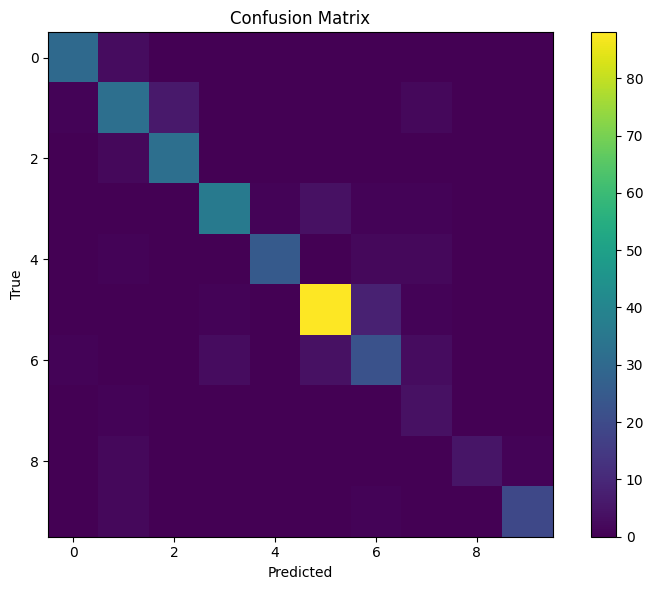

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

cm_df = pd.DataFrame(cm)
cm_df.to_csv(RUN_DIR / "confusion_matrix.csv", index=False)

In [23]:
summary_row = {
    "run_name": run_name,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "test_loss": test_loss,
    **test_metrics
}

summary_df = pd.DataFrame([summary_row])
display(summary_df)

summary_csv = RUN_DIR / "run_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
print("All outputs saved in:", RUN_DIR)

,run_name,seed,model_name,optimizer_name,best_epoch,best_val_macro_f1,test_loss,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,mobilenetv3_small__adamw__weightedCE_True__lab...,42,mobilenetv3_small,adamw,13,0.785566,0.999508,0.84438,0.820675,0.815456,0.801657,0.862397,0.84438,0.849765


Saved: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42/run_summary.csv
All outputs saved in: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42


In [24]:
saved_files = sorted([p.name for p in RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)

Saved files:
- accuracy_curve.png
- best_model.pth
- classification_report.txt
- config.json
- confusion_matrix.csv
- confusion_matrix.png
- loss_curve.png
- metrics_test.json
- run_summary.csv
- test_predictions.csv
- train_log.csv
- val_predictions.csv


In [29]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm import tqdm

warnings.filterwarnings("ignore")
print("Imports loaded successfully.")

Imports loaded successfully.


In [30]:
from pathlib import Path

# Auto-detect Windows / WSL path
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- CONFIG ----------------
SEED = 42
MODEL_NAME = "customcnn_bn"   
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 8
NUM_WORKERS = 0
IMAGE_SIZE = 224

USE_PRETRAINED = False
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = False
LABEL_SMOOTHING = 0.0

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("Exists      :", SPLIT_CSV.exists())
print("MODEL_NAME  :", MODEL_NAME)

BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_42.csv
Exists      : True
MODEL_NAME  : customcnn_bn


In [54]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [55]:
split_df = pd.read_csv(SPLIT_CSV)

print("Split dataframe shape:", split_df.shape)
display(split_df.head())

print("\nSplit counts:")
print(split_df["split"].value_counts())

print("\nUnique classes per split:")
print(split_df.groupby("split")["class_id"].nunique())

Split dataframe shape: (2312, 14)


,dataset,filepath,relative_path,filename,class_id,class_name,width,height,mode,file_size_bytes,md5,read_error,split,seed
0,GC10,/mnt/e/CVPR/GC10/6/img_05_4406743300_00516.jpg,6/img_05_4406743300_00516.jpg,img_05_4406743300_00516.jpg,6,class_6,2048,1000,L,417074,15278af3890244410b468f9d0f18843c,NaN,train,42
1,GC10,/mnt/e/CVPR/GC10/4/img_03_424798500_00466.jpg,4/img_03_424798500_00466.jpg,img_03_424798500_00466.jpg,4,class_4,2048,1000,L,336170,4559975600be63ab9d342532102e6772,NaN,train,42
2,GC10,/mnt/e/CVPR/GC10/5/img_04_425503600_00019.jpg,5/img_04_425503600_00019.jpg,img_04_425503600_00019.jpg,5,class_5,2048,1000,L,389149,fe62220be3d57b4a3977d1cdc56f014b,NaN,train,42
3,GC10,/mnt/e/CVPR/GC10/6/img_06_3436814300_00056.jpg,6/img_06_3436814300_00056.jpg,img_06_3436814300_00056.jpg,6,class_6,2048,1000,L,450002,0a0264c5e0d27aa71b83ae0cb56b55e9,NaN,train,42
4,GC10,/mnt/e/CVPR/GC10/6/img_08_4406743300_00470.jpg,6/img_08_4406743300_00470.jpg,img_08_4406743300_00470.jpg,6,class_6,2048,1000,L,382174,845a8cf42a9612dc6b6d028511373132,NaN,train,42



Split counts:
split
train    1618
val       347
test      347
Name: count, dtype: int64

Unique classes per split:
split
test     10
train    10
val      10
Name: class_id, dtype: int64


In [56]:
def normalize_path(path_str):
    path_str = str(path_str)

    p = Path(path_str)
    if p.exists():
        return str(p)

    # Windows path -> WSL path
    if len(path_str) >= 3 and path_str[1:3] == ":\\":
        drive = path_str[0].lower()
        rest = path_str[3:].replace("\\", "/")
        wsl_path = f"/mnt/{drive}/{rest}"
        if Path(wsl_path).exists():
            return wsl_path

    # WSL path -> Windows path
    if path_str.startswith("/mnt/") and len(path_str) > 7:
        drive = path_str[5]
        rest = path_str[7:].replace("/", "\\")
        win_path = f"{drive.upper()}:\\{rest}"
        if Path(win_path).exists():
            return win_path

    return path_str

split_df["filepath"] = split_df["filepath"].apply(normalize_path)

print("Path existence check:")
for i in range(5):
    p = split_df.iloc[i]["filepath"]
    print(p, "->", Path(p).exists())

Path existence check:
/mnt/e/CVPR/GC10/6/img_05_4406743300_00516.jpg -> True
/mnt/e/CVPR/GC10/4/img_03_424798500_00466.jpg -> True
/mnt/e/CVPR/GC10/5/img_04_425503600_00019.jpg -> True
/mnt/e/CVPR/GC10/6/img_06_3436814300_00056.jpg -> True
/mnt/e/CVPR/GC10/6/img_08_4406743300_00470.jpg -> True


In [57]:
train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df  = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain class counts:")
print(train_df["class_id"].value_counts().sort_index())

Train: (1618, 14)
Val  : (347, 14)
Test : (347, 14)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64


In [58]:
basic_transform_for_stats = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

class TempImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        img = self.transform(img)
        return img

temp_ds = TempImageDataset(train_df, basic_transform_for_stats)
temp_loader = DataLoader(
    temp_ds,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in tqdm(temp_loader, desc="Computing mean/std"):
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
    num_pixels += images.size(0) * images.size(2) * images.size(3)

train_mean = channel_sum / num_pixels
train_std = torch.sqrt(channel_sq_sum / num_pixels - train_mean ** 2)

print("Train mean:", train_mean.tolist())
print("Train std :", train_std.tolist())

Computing mean/std: 100%|███████████████████████████████████████████████████████████████| 51/51 [00:25<00:00,  1.98it/s]

Train mean: [0.3359968066215515, 0.3359968066215515, 0.3359968066215515]
Train std : [0.1534603238105774, 0.1534603238105774, 0.1534603238105774]


In [59]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

print("Transforms ready.")

Transforms ready.


In [60]:
class GC10Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = int(row["class_id"]) - 1  # 1..10 -> 0..9

        img = Image.open(img_path).convert("L")
        img = self.transform(img)

        return img, label, img_path

In [61]:
train_ds = GC10Dataset(train_df, train_transform)
val_ds   = GC10Dataset(val_df, eval_transform)
test_ds  = GC10Dataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 51
Val batches  : 11
Test batches : 11


In [62]:
class CustomCNNBase(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CustomCNNBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CustomCNNDrop(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_model(model_name, num_classes=10):
    if model_name == "customcnn_base":
        return CustomCNNBase(num_classes=num_classes)
    elif model_name == "customcnn_bn":
        return CustomCNNBN(num_classes=num_classes)
    elif model_name == "customcnn_drop":
        return CustomCNNDrop(num_classes=num_classes)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

In [63]:
class CustomCNNBase(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CustomCNNBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CustomCNNDrop(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_model(model_name, num_classes=10):
    if model_name == "customcnn_base":
        return CustomCNNBase(num_classes=num_classes)
    elif model_name == "customcnn_bn":
        return CustomCNNBN(num_classes=num_classes)
    elif model_name == "customcnn_drop":
        return CustomCNNDrop(num_classes=num_classes)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

In [64]:
model = build_model(MODEL_NAME, num_classes=NUM_CLASSES).to(DEVICE)

train_class_counts = train_df["class_id"].value_counts().sort_index()
print("Train class counts:")
print(train_class_counts)

class_weights = []
total_train = len(train_df)

for class_id in range(1, NUM_CLASSES + 1):
    count = int(train_class_counts[class_id])
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights)

if USE_WEIGHTED_LOSS and USE_LABEL_SMOOTHING:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING
    )
elif USE_WEIGHTED_LOSS:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

if OPTIMIZER_NAME == "adamw":
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER_NAME == "sgd":
    optimizer = optim.SGD(
        model.parameters(),
        lr=1e-2,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY,
        nesterov=True
    )
else:
    raise ValueError("Unsupported optimizer")

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model)
print("\nCriterion:", criterion)
print("Optimizer:", optimizer)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64
Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')
CustomCNNDrop(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11)

In [65]:
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

In [66]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)
    return epoch_loss, metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []
    all_paths = []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_logits.extend(outputs.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)

    pred_df = pd.DataFrame({
        "filepath": all_paths,
        "y_true": all_labels,
        "y_pred": all_preds,
    })

    probs_np = np.array(all_probs)
    logits_np = np.array(all_logits)

    for c in range(probs_np.shape[1]):
        pred_df[f"prob_class_{c}"] = probs_np[:, c]
        pred_df[f"logit_class_{c}"] = logits_np[:, c]

    return epoch_loss, metrics, pred_df

In [67]:
run_name = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)

RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "image_size": IMAGE_SIZE,
    "num_workers": NUM_WORKERS,
    "split_csv": str(SPLIT_CSV),
    "train_mean": train_mean.tolist(),
    "train_std": train_std.tolist(),
    "use_pretrained": USE_PRETRAINED,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_label_smoothing": USE_LABEL_SMOOTHING,
    "label_smoothing": LABEL_SMOOTHING,
}

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("RUN_DIR:", RUN_DIR)

RUN_DIR: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/customcnn_drop__adamw__weightedCE_True__labelsmooth_False__pretrained_False__seed_42


In [68]:
history = []
best_val_f1 = -1.0
best_epoch = -1
best_val_df = None
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_metrics, val_pred_df = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        best_val_df = val_pred_df.copy()
        epochs_without_improvement = 0

        torch.save(model.state_dict(), RUN_DIR / "best_model.pth")
        best_val_df.to_csv(RUN_DIR / "val_predictions.csv", index=False)

        print("Best model updated.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "train_log.csv", index=False)

print("\nBest epoch:", best_epoch)
print("Best val macro-F1:", best_val_f1)


Epoch 1/40


train_loss=2.2406 | val_loss=2.2102 | train_macro_f1=0.0759 | val_macro_f1=0.0435
Best model updated.

Epoch 2/40


train_loss=2.1786 | val_loss=2.1266 | train_macro_f1=0.1188 | val_macro_f1=0.1115
Best model updated.

Epoch 3/40


train_loss=2.1604 | val_loss=2.1119 | train_macro_f1=0.1289 | val_macro_f1=0.0714

Epoch 4/40


train_loss=2.1371 | val_loss=2.0865 | train_macro_f1=0.1096 | val_macro_f1=0.1076

Epoch 5/40


...

train_loss=1.3831 | val_loss=1.4363 | train_macro_f1=0.4429 | val_macro_f1=0.3832

Epoch 37/40


train_loss=1.4011 | val_loss=1.4296 | train_macro_f1=0.4466 | val_macro_f1=0.3782

Epoch 38/40


train_loss=1.3903 | val_loss=1.4372 | train_macro_f1=0.4300 | val_macro_f1=0.3678

Epoch 39/40


train_loss=1.3737 | val_loss=1.4327 | train_macro_f1=0.4422 | val_macro_f1=0.3775

Epoch 40/40


train_loss=1.3639 | val_loss=1.4318 | train_macro_f1=0.4408 | val_macro_f1=0.3775

Best epoch: 33
Best val macro-F1: 0.38595885858530277


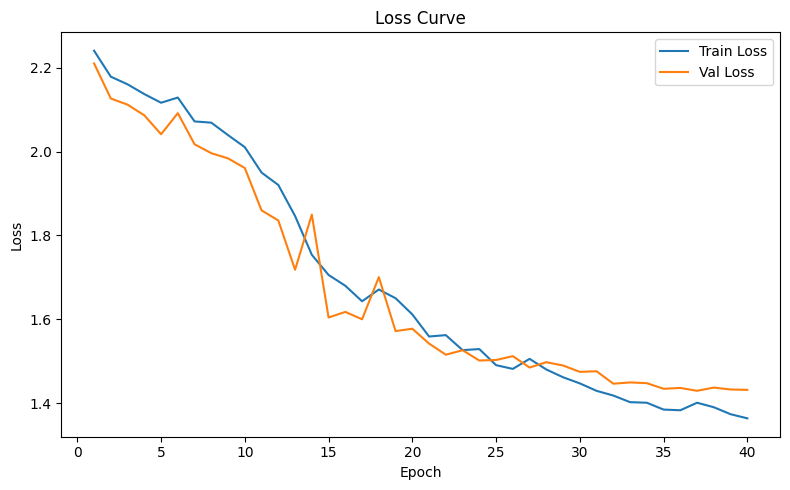

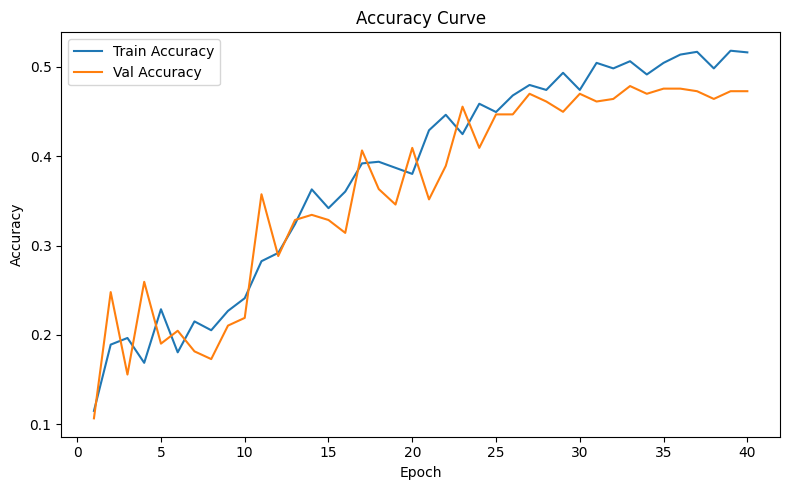

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

In [70]:
best_model = build_model(MODEL_NAME, num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load(RUN_DIR / "best_model.pth", map_location=DEVICE))

test_loss, test_metrics, test_pred_df = evaluate(best_model, test_loader, criterion, DEVICE)

print("Test loss:", round(test_loss, 4))
print(json.dumps(test_metrics, indent=2))

test_pred_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

Test loss: 1.369
{
  "accuracy": 0.484149855907781,
  "macro_precision": 0.45265815104069274,
  "macro_recall": 0.5025063820712113,
  "macro_f1": 0.416588489398087,
  "weighted_precision": 0.5919035822658659,
  "weighted_recall": 0.484149855907781,
  "weighted_f1": 0.4794072610297037
}


In [71]:
with open(RUN_DIR / "metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
            "test_loss": float(test_loss),
            **{k: float(v) for k, v in test_metrics.items()}
        },
        f,
        indent=2
    )

print("Saved metrics_test.json")

Saved metrics_test.json


In [72]:
y_true = test_pred_df["y_true"].values
y_pred = test_pred_df["y_pred"].values

report = classification_report(y_true, y_pred, digits=4, zero_division=0)
print(report)

with open(RUN_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

              precision    recall  f1-score   support

           0     0.7561    0.9394    0.8378        33
           1     0.7000    0.1707    0.2745        41
           2     0.5926    0.9412    0.7273        34
           3     0.5676    0.4884    0.5250        43
           4     0.2500    0.0667    0.1053        30
           5     0.8571    0.4286    0.5714        98
           6     0.2545    0.4242    0.3182        33
           7     0.1579    0.6000    0.2500         5
           8     0.1500    0.3750    0.2143         8
           9     0.2407    0.5909    0.3421        22

    accuracy                         0.4841       347
   macro avg     0.4527    0.5025    0.4166       347
weighted avg     0.5919    0.4841    0.4794       347



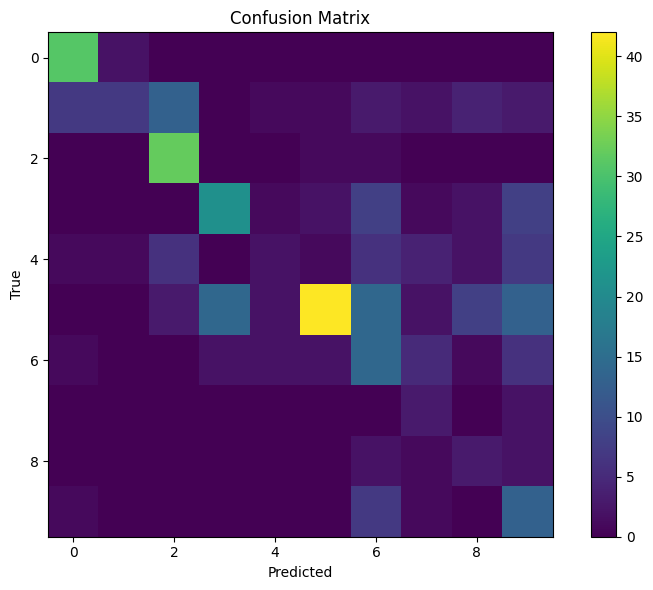

In [73]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

cm_df = pd.DataFrame(cm)
cm_df.to_csv(RUN_DIR / "confusion_matrix.csv", index=False)

In [74]:
summary_row = {
    "run_name": run_name,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "test_loss": test_loss,
    **test_metrics
}

summary_df = pd.DataFrame([summary_row])
display(summary_df)

summary_csv = RUN_DIR / "run_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
print("All outputs saved in:", RUN_DIR)

,run_name,seed,model_name,optimizer_name,best_epoch,best_val_macro_f1,test_loss,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,customcnn_drop__adamw__weightedCE_True__labels...,42,customcnn_drop,adamw,33,0.385959,1.368961,0.48415,0.452658,0.502506,0.416588,0.591904,0.48415,0.479407


Saved: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/customcnn_drop__adamw__weightedCE_True__labelsmooth_False__pretrained_False__seed_42/run_summary.csv
All outputs saved in: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/customcnn_drop__adamw__weightedCE_True__labelsmooth_False__pretrained_False__seed_42


In [75]:
saved_files = sorted([p.name for p in RUN_DIR.iterdir()])
print("Saved files:")
for f in saved_files:
    print("-", f)

Saved files:
- accuracy_curve.png
- best_model.pth
- classification_report.txt
- config.json
- confusion_matrix.csv
- confusion_matrix.png
- loss_curve.png
- metrics_test.json
- run_summary.csv
- test_predictions.csv
- train_log.csv
- val_predictions.csv


In [53]:
from pathlib import Path

# Auto-detect Windows / WSL path
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- CONFIG ----------------
SEED = 42
MODEL_NAME = "customcnn_drop"
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 8
NUM_WORKERS = 0
IMAGE_SIZE = 224

USE_PRETRAINED = False
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = False
LABEL_SMOOTHING = 0.0

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("Exists      :", SPLIT_CSV.exists())
print("MODEL_NAME  :", MODEL_NAME)

BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_42.csv
Exists      : True
MODEL_NAME  : customcnn_drop


BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_13.csv
MODEL_NAME  : mobilenetv3_small
SEED        : 13
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti

Split sizes:
Train: (1618, 14)
Val  : (347, 14)
Test : (347, 14)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64


Computing mean/std: 100%|███████████████████████████████████████████████████████████████| 51/51 [00:27<00:00,  1.87it/s]



Train mean: [0.3364817500114441, 0.3364817500114441, 0.3364817500114441]
Train std : [0.15469388663768768, 0.15469388663768768, 0.15469388663768768]

Batches:
Train: 51
Val  : 11
Test : 11

Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')

RUN_DIR: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13

Epoch 1/30


train_loss=2.2180 | val_loss=2.2763 | train_macro_f1=0.2439 | val_macro_f1=0.2717
Best model updated.

Epoch 2/30


train_loss=1.6895 | val_loss=1.9646 | train_macro_f1=0.5224 | val_macro_f1=0.5136
Best model updated.

Epoch 3/30


...

train_loss=0.6133 | val_loss=1.0341 | train_macro_f1=0.9523 | val_macro_f1=0.7733

Epoch 27/30


train_loss=0.5923 | val_loss=1.0300 | train_macro_f1=0.9706 | val_macro_f1=0.7741

Epoch 28/30


train_loss=0.5978 | val_loss=1.0319 | train_macro_f1=0.9518 | val_macro_f1=0.7762

Epoch 29/30


train_loss=0.5962 | val_loss=1.0335 | train_macro_f1=0.9629 | val_macro_f1=0.7762

Epoch 30/30


train_loss=0.5935 | val_loss=1.0314 | train_macro_f1=0.9624 | val_macro_f1=0.7745

Best epoch: 23
Best val macro-F1: 0.7916440568955326


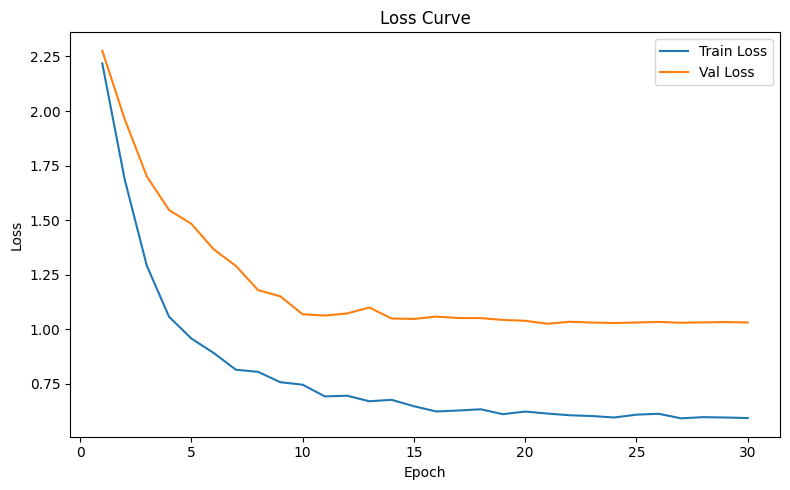

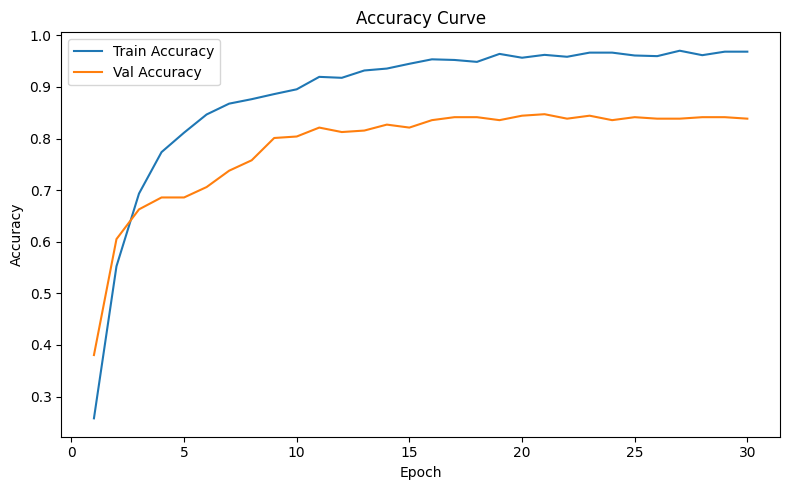


Test loss: 0.9678
{
  "accuracy": 0.8760806916426513,
  "macro_precision": 0.7852728667728667,
  "macro_recall": 0.7956706962164023,
  "macro_f1": 0.7876333460371676,
  "weighted_precision": 0.8785243550229141,
  "weighted_recall": 0.8760806916426513,
  "weighted_f1": 0.8751865971837937
}

Classification Report:

              precision    recall  f1-score   support

           0     0.9091    0.9091    0.9091        33
           1     0.8462    0.8049    0.8250        41
           2     0.8649    0.9412    0.9014        34
           3     0.9500    0.8636    0.9048        44
           4     0.7143    0.8333    0.7692        30
           5     0.9600    0.9796    0.9697        98
           6     0.8000    0.6250    0.7018        32
           7     0.2500    0.2500    0.2500         4
           8     0.6000    0.7500    0.6667         8
           9     0.9583    1.0000    0.9787        23

    accuracy                         0.8761       347
   macro avg     0.7853    0.7957 

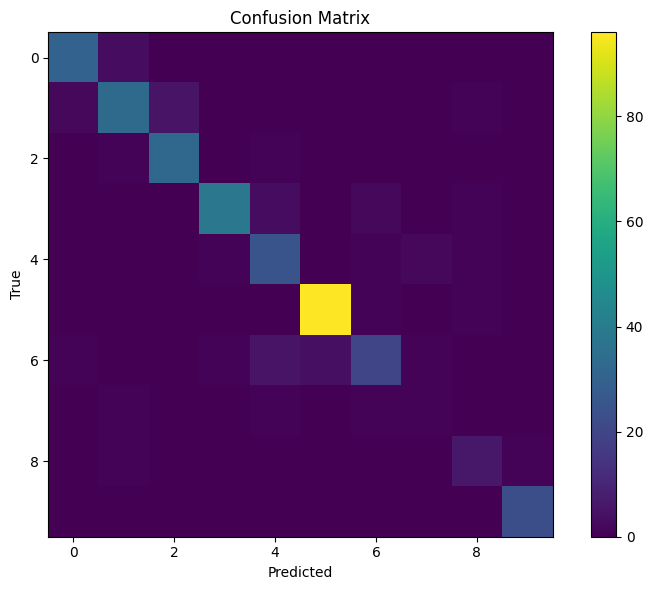


Saved summary:
                                            run_name  seed         model_name  \
0  mobilenetv3_small__adamw__weightedCE_True__lab...    13  mobilenetv3_small   

  optimizer_name  best_epoch  best_val_macro_f1  test_loss  accuracy  \
0          adamw          23           0.791644   0.967768  0.876081   

   macro_precision  macro_recall  macro_f1  weighted_precision  \
0         0.785273      0.795671  0.787633            0.878524   

   weighted_recall  weighted_f1  
0         0.876081     0.875187  

Saved files:
- accuracy_curve.png
- best_model.pth
- classification_report.txt
- config.json
- confusion_matrix.csv
- confusion_matrix.png
- loss_curve.png
- metrics_test.json
- run_summary.csv
- test_predictions.csv
- train_log.csv
- val_predictions.csv


In [76]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from tqdm import tqdm

warnings.filterwarnings("ignore")

# =========================
# CONFIG
# =========================
SEED = 13   # CHANGE ONLY THIS: 13 or 87

MODEL_NAME = "mobilenetv3_small"
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 8
NUM_WORKERS = 0
IMAGE_SIZE = 224

USE_PRETRAINED = True
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
LABEL_SMOOTHING = 0.05

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"
if not SPLIT_CSV.exists():
    raise FileNotFoundError(f"Split CSV not found: {SPLIT_CSV}")

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("MODEL_NAME  :", MODEL_NAME)
print("SEED        :", SEED)

# =========================
# SEED + DEVICE
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# LOAD SPLIT
# =========================
split_df = pd.read_csv(SPLIT_CSV)

def normalize_path(path_str):
    path_str = str(path_str)
    p = Path(path_str)
    if p.exists():
        return str(p)

    if len(path_str) >= 3 and path_str[1:3] == ":\\":
        drive = path_str[0].lower()
        rest = path_str[3:].replace("\\", "/")
        wsl_path = f"/mnt/{drive}/{rest}"
        if Path(wsl_path).exists():
            return wsl_path

    if path_str.startswith("/mnt/") and len(path_str) > 7:
        drive = path_str[5]
        rest = path_str[7:].replace("/", "\\")
        win_path = f"{drive.upper()}:\\{rest}"
        if Path(win_path).exists():
            return win_path

    return path_str

split_df["filepath"] = split_df["filepath"].apply(normalize_path)

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df  = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain class counts:")
print(train_df["class_id"].value_counts().sort_index())

# =========================
# COMPUTE TRAIN MEAN / STD
# =========================
basic_transform_for_stats = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

class TempImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        img = self.transform(img)
        return img

temp_ds = TempImageDataset(train_df, basic_transform_for_stats)
temp_loader = DataLoader(
    temp_ds,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in tqdm(temp_loader, desc="Computing mean/std"):
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
    num_pixels += images.size(0) * images.size(2) * images.size(3)

train_mean = channel_sum / num_pixels
train_std = torch.sqrt(channel_sq_sum / num_pixels - train_mean ** 2)

print("\nTrain mean:", train_mean.tolist())
print("Train std :", train_std.tolist())

# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

# =========================
# DATASET / DATALOADER
# =========================
class GC10Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = int(row["class_id"]) - 1  # 1..10 -> 0..9
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, label, img_path

train_ds = GC10Dataset(train_df, train_transform)
val_ds   = GC10Dataset(val_df, eval_transform)
test_ds  = GC10Dataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("\nBatches:")
print("Train:", len(train_loader))
print("Val  :", len(val_loader))
print("Test :", len(test_loader))

# =========================
# MODEL
# =========================
def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)

# =========================
# LOSS / OPTIMIZER / SCHEDULER
# =========================
train_class_counts = train_df["class_id"].value_counts().sort_index()

class_weights = []
total_train = len(train_df)
for class_id in range(1, NUM_CLASSES + 1):
    count = int(train_class_counts[class_id])
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("\nClass weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# =========================
# METRICS
# =========================
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)
    return epoch_loss, metrics

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []
    all_paths = []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_logits.extend(outputs.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)

    pred_df = pd.DataFrame({
        "filepath": all_paths,
        "y_true": all_labels,
        "y_pred": all_preds,
    })

    probs_np = np.array(all_probs)
    logits_np = np.array(all_logits)

    for c in range(probs_np.shape[1]):
        pred_df[f"prob_class_{c}"] = probs_np[:, c]
        pred_df[f"logit_class_{c}"] = logits_np[:, c]

    return epoch_loss, metrics, pred_df

# =========================
# RUN DIR
# =========================
run_name = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)
RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "image_size": IMAGE_SIZE,
    "num_workers": NUM_WORKERS,
    "split_csv": str(SPLIT_CSV),
    "train_mean": train_mean.tolist(),
    "train_std": train_std.tolist(),
    "use_pretrained": USE_PRETRAINED,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_label_smoothing": USE_LABEL_SMOOTHING,
    "label_smoothing": LABEL_SMOOTHING,
}

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("\nRUN_DIR:", RUN_DIR)

# =========================
# TRAIN LOOP
# =========================
history = []
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_metrics, val_pred_df = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(model.state_dict(), RUN_DIR / "best_model.pth")
        val_pred_df.to_csv(RUN_DIR / "val_predictions.csv", index=False)
        print("Best model updated.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "train_log.csv", index=False)

print("\nBest epoch:", best_epoch)
print("Best val macro-F1:", best_val_f1)

# =========================
# PLOTS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

# =========================
# TEST
# =========================
best_model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)
best_model.load_state_dict(torch.load(RUN_DIR / "best_model.pth", map_location=DEVICE))

test_loss, test_metrics, test_pred_df = evaluate(best_model, test_loader, criterion, DEVICE)

print("\nTest loss:", round(test_loss, 4))
print(json.dumps(test_metrics, indent=2))

test_pred_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

with open(RUN_DIR / "metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
            "test_loss": float(test_loss),
            **{k: float(v) for k, v in test_metrics.items()}
        },
        f,
        indent=2
    )

# =========================
# REPORT + CONFUSION MATRIX
# =========================
y_true = test_pred_df["y_true"].values
y_pred = test_pred_df["y_pred"].values

report = classification_report(y_true, y_pred, digits=4, zero_division=0)
print("\nClassification Report:\n")
print(report)

with open(RUN_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm)
cm_df.to_csv(RUN_DIR / "confusion_matrix.csv", index=False)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# =========================
# SUMMARY
# =========================
summary_row = {
    "run_name": run_name,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "test_loss": test_loss,
    **test_metrics
}
summary_df = pd.DataFrame([summary_row])
summary_df.to_csv(RUN_DIR / "run_summary.csv", index=False)

print("\nSaved summary:")
print(summary_df)

print("\nSaved files:")
for f in sorted([p.name for p in RUN_DIR.iterdir()]):
    print("-", f)

BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_87.csv
MODEL_NAME  : mobilenetv3_small
SEED        : 87
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti

Split sizes:
Train: (1618, 14)
Val  : (347, 14)
Test : (347, 14)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64


Computing mean/std: 100%|███████████████████████████████████████████████████████████████| 51/51 [00:27<00:00,  1.88it/s]



Train mean: [0.3348475992679596, 0.3348475992679596, 0.3348475992679596]
Train std : [0.15359212458133698, 0.15359212458133698, 0.15359212458133698]

Batches:
Train: 51
Val  : 11
Test : 11

Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')

RUN_DIR: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87

Epoch 1/30


train_loss=2.2747 | val_loss=2.3493 | train_macro_f1=0.2226 | val_macro_f1=0.1549
Best model updated.

Epoch 2/30


train_loss=1.7771 | val_loss=2.1510 | train_macro_f1=0.4460 | val_macro_f1=0.2953
Best model updated.

Epoch 3/30


...

train_loss=0.6052 | val_loss=1.0877 | train_macro_f1=0.9623 | val_macro_f1=0.7656

Epoch 24/30


train_loss=0.5983 | val_loss=1.0932 | train_macro_f1=0.9656 | val_macro_f1=0.7742

Epoch 25/30


train_loss=0.5964 | val_loss=1.0906 | train_macro_f1=0.9660 | val_macro_f1=0.7651

Epoch 26/30


train_loss=0.5944 | val_loss=1.0912 | train_macro_f1=0.9717 | val_macro_f1=0.7666

Epoch 27/30


train_loss=0.6034 | val_loss=1.0911 | train_macro_f1=0.9561 | val_macro_f1=0.7653
Early stopping triggered at epoch 27.

Best epoch: 19
Best val macro-F1: 0.7833164121166049


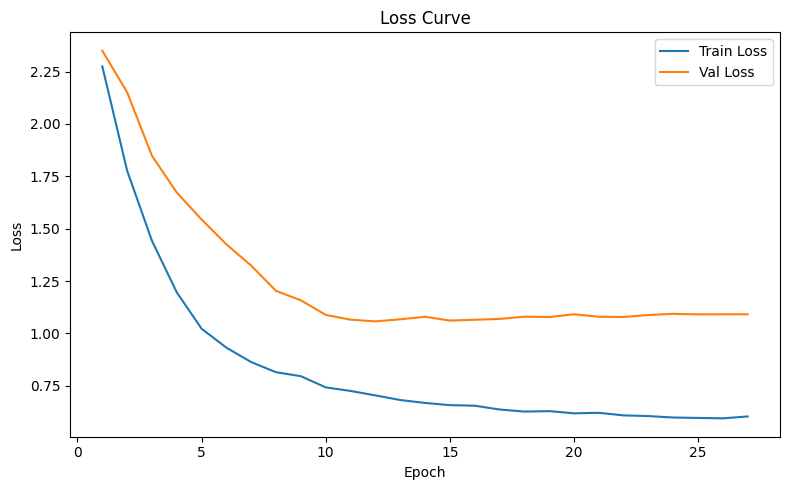

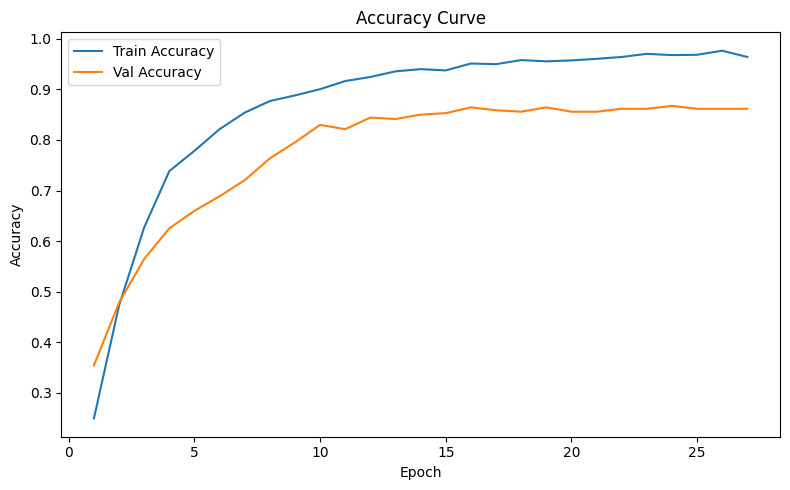


Test loss: 1.0626
{
  "accuracy": 0.8472622478386167,
  "macro_precision": 0.7734580200170555,
  "macro_recall": 0.7913058610299732,
  "macro_f1": 0.773547212117222,
  "weighted_precision": 0.8531686098949908,
  "weighted_recall": 0.8472622478386167,
  "weighted_f1": 0.8461522651678486
}

Classification Report:

              precision    recall  f1-score   support

           0     0.7143    0.9091    0.8000        33
           1     0.8387    0.6341    0.7222        41
           2     0.9143    0.9412    0.9275        34
           3     0.8974    0.8140    0.8537        43
           4     0.8276    0.8000    0.8136        30
           5     0.9495    0.9691    0.9592        97
           6     0.7353    0.7576    0.7463        33
           7     0.4444    0.8000    0.5714         5
           8     0.5000    0.3750    0.4286         8
           9     0.9130    0.9130    0.9130        23

    accuracy                         0.8473       347
   macro avg     0.7735    0.7913  

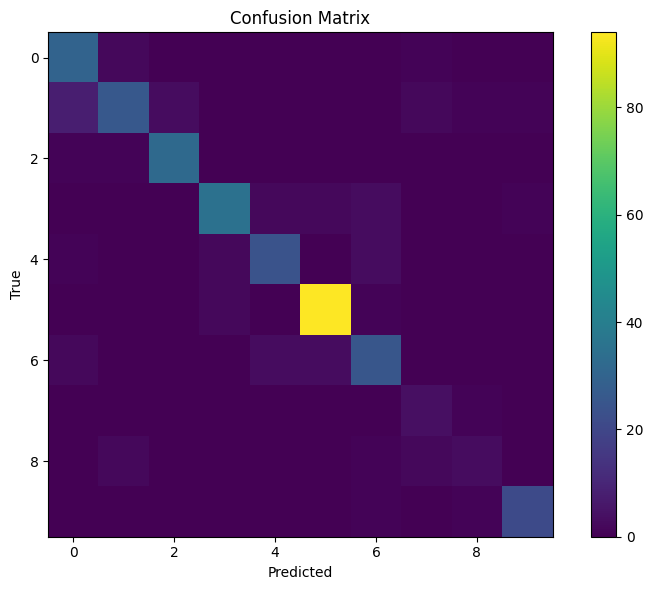


Saved summary:
                                            run_name  seed         model_name  \
0  mobilenetv3_small__adamw__weightedCE_True__lab...    87  mobilenetv3_small   

  optimizer_name  best_epoch  best_val_macro_f1  test_loss  accuracy  \
0          adamw          19           0.783316   1.062584  0.847262   

   macro_precision  macro_recall  macro_f1  weighted_precision  \
0         0.773458      0.791306  0.773547            0.853169   

   weighted_recall  weighted_f1  
0         0.847262     0.846152  

Saved files:
- accuracy_curve.png
- best_model.pth
- classification_report.txt
- config.json
- confusion_matrix.csv
- confusion_matrix.png
- loss_curve.png
- metrics_test.json
- run_summary.csv
- test_predictions.csv
- train_log.csv
- val_predictions.csv


In [77]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from tqdm import tqdm

warnings.filterwarnings("ignore")

# =========================
# CONFIG
# =========================
SEED = 87   # CHANGE ONLY THIS: 13 or 87

MODEL_NAME = "mobilenetv3_small"
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 8
NUM_WORKERS = 0
IMAGE_SIZE = 224

USE_PRETRAINED = True
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
LABEL_SMOOTHING = 0.05

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"
if not SPLIT_CSV.exists():
    raise FileNotFoundError(f"Split CSV not found: {SPLIT_CSV}")

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("MODEL_NAME  :", MODEL_NAME)
print("SEED        :", SEED)

# =========================
# SEED + DEVICE
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# LOAD SPLIT
# =========================
split_df = pd.read_csv(SPLIT_CSV)

def normalize_path(path_str):
    path_str = str(path_str)
    p = Path(path_str)
    if p.exists():
        return str(p)

    if len(path_str) >= 3 and path_str[1:3] == ":\\":
        drive = path_str[0].lower()
        rest = path_str[3:].replace("\\", "/")
        wsl_path = f"/mnt/{drive}/{rest}"
        if Path(wsl_path).exists():
            return wsl_path

    if path_str.startswith("/mnt/") and len(path_str) > 7:
        drive = path_str[5]
        rest = path_str[7:].replace("/", "\\")
        win_path = f"{drive.upper()}:\\{rest}"
        if Path(win_path).exists():
            return win_path

    return path_str

split_df["filepath"] = split_df["filepath"].apply(normalize_path)

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df  = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain class counts:")
print(train_df["class_id"].value_counts().sort_index())

# =========================
# COMPUTE TRAIN MEAN / STD
# =========================
basic_transform_for_stats = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

class TempImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        img = self.transform(img)
        return img

temp_ds = TempImageDataset(train_df, basic_transform_for_stats)
temp_loader = DataLoader(
    temp_ds,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in tqdm(temp_loader, desc="Computing mean/std"):
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
    num_pixels += images.size(0) * images.size(2) * images.size(3)

train_mean = channel_sum / num_pixels
train_std = torch.sqrt(channel_sq_sum / num_pixels - train_mean ** 2)

print("\nTrain mean:", train_mean.tolist())
print("Train std :", train_std.tolist())

# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

# =========================
# DATASET / DATALOADER
# =========================
class GC10Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = int(row["class_id"]) - 1  # 1..10 -> 0..9
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, label, img_path

train_ds = GC10Dataset(train_df, train_transform)
val_ds   = GC10Dataset(val_df, eval_transform)
test_ds  = GC10Dataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("\nBatches:")
print("Train:", len(train_loader))
print("Val  :", len(val_loader))
print("Test :", len(test_loader))

# =========================
# MODEL
# =========================
def build_mobilenetv3_small(num_classes=10, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)

# =========================
# LOSS / OPTIMIZER / SCHEDULER
# =========================
train_class_counts = train_df["class_id"].value_counts().sort_index()

class_weights = []
total_train = len(train_df)
for class_id in range(1, NUM_CLASSES + 1):
    count = int(train_class_counts[class_id])
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("\nClass weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# =========================
# METRICS
# =========================
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)
    return epoch_loss, metrics

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []
    all_paths = []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_logits.extend(outputs.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)

    pred_df = pd.DataFrame({
        "filepath": all_paths,
        "y_true": all_labels,
        "y_pred": all_preds,
    })

    probs_np = np.array(all_probs)
    logits_np = np.array(all_logits)

    for c in range(probs_np.shape[1]):
        pred_df[f"prob_class_{c}"] = probs_np[:, c]
        pred_df[f"logit_class_{c}"] = logits_np[:, c]

    return epoch_loss, metrics, pred_df

# =========================
# RUN DIR
# =========================
run_name = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)
RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "image_size": IMAGE_SIZE,
    "num_workers": NUM_WORKERS,
    "split_csv": str(SPLIT_CSV),
    "train_mean": train_mean.tolist(),
    "train_std": train_std.tolist(),
    "use_pretrained": USE_PRETRAINED,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_label_smoothing": USE_LABEL_SMOOTHING,
    "label_smoothing": LABEL_SMOOTHING,
}

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("\nRUN_DIR:", RUN_DIR)

# =========================
# TRAIN LOOP
# =========================
history = []
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_metrics, val_pred_df = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(model.state_dict(), RUN_DIR / "best_model.pth")
        val_pred_df.to_csv(RUN_DIR / "val_predictions.csv", index=False)
        print("Best model updated.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "train_log.csv", index=False)

print("\nBest epoch:", best_epoch)
print("Best val macro-F1:", best_val_f1)

# =========================
# PLOTS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

# =========================
# TEST
# =========================
best_model = build_mobilenetv3_small(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)
best_model.load_state_dict(torch.load(RUN_DIR / "best_model.pth", map_location=DEVICE))

test_loss, test_metrics, test_pred_df = evaluate(best_model, test_loader, criterion, DEVICE)

print("\nTest loss:", round(test_loss, 4))
print(json.dumps(test_metrics, indent=2))

test_pred_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

with open(RUN_DIR / "metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
            "test_loss": float(test_loss),
            **{k: float(v) for k, v in test_metrics.items()}
        },
        f,
        indent=2
    )

# =========================
# REPORT + CONFUSION MATRIX
# =========================
y_true = test_pred_df["y_true"].values
y_pred = test_pred_df["y_pred"].values

report = classification_report(y_true, y_pred, digits=4, zero_division=0)
print("\nClassification Report:\n")
print(report)

with open(RUN_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm)
cm_df.to_csv(RUN_DIR / "confusion_matrix.csv", index=False)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# =========================
# SUMMARY
# =========================
summary_row = {
    "run_name": run_name,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "test_loss": test_loss,
    **test_metrics
}
summary_df = pd.DataFrame([summary_row])
summary_df.to_csv(RUN_DIR / "run_summary.csv", index=False)

print("\nSaved summary:")
print(summary_df)

print("\nSaved files:")
for f in sorted([p.name for p in RUN_DIR.iterdir()]):
    print("-", f)

BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_13.csv
MODEL_NAME  : resnet18
SEED        : 13
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti

Split sizes:
Train: (1618, 14)
Val  : (347, 14)
Test : (347, 14)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64


Computing mean/std: 100%|███████████████████████████████████████████████████████████████| 51/51 [00:25<00:00,  1.97it/s]



Train mean: [0.3364817500114441, 0.3364817500114441, 0.3364817500114441]
Train std : [0.15469388663768768, 0.15469388663768768, 0.15469388663768768]

Batches:
Train: 51
Val  : 11
Test : 11

Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')

RUN_DIR: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13

Epoch 1/30


train_loss=1.6231 | val_loss=1.2110 | train_macro_f1=0.5208 | val_macro_f1=0.6815
Best model updated.

Epoch 2/30


train_loss=0.9382 | val_loss=1.0624 | train_macro_f1=0.8050 | val_macro_f1=0.7414
Best model updated.

Epoch 3/30


...

train_loss=0.5065 | val_loss=0.9075 | train_macro_f1=0.9897 | val_macro_f1=0.8359

Epoch 17/30


train_loss=0.5035 | val_loss=0.9139 | train_macro_f1=0.9911 | val_macro_f1=0.8338

Epoch 18/30


train_loss=0.5012 | val_loss=0.9239 | train_macro_f1=0.9920 | val_macro_f1=0.7957

Epoch 19/30


train_loss=0.4963 | val_loss=0.9269 | train_macro_f1=0.9920 | val_macro_f1=0.8052

Epoch 20/30


train_loss=0.5066 | val_loss=0.9207 | train_macro_f1=0.9903 | val_macro_f1=0.8006
Early stopping triggered at epoch 20.

Best epoch: 12
Best val macro-F1: 0.8392795023197925


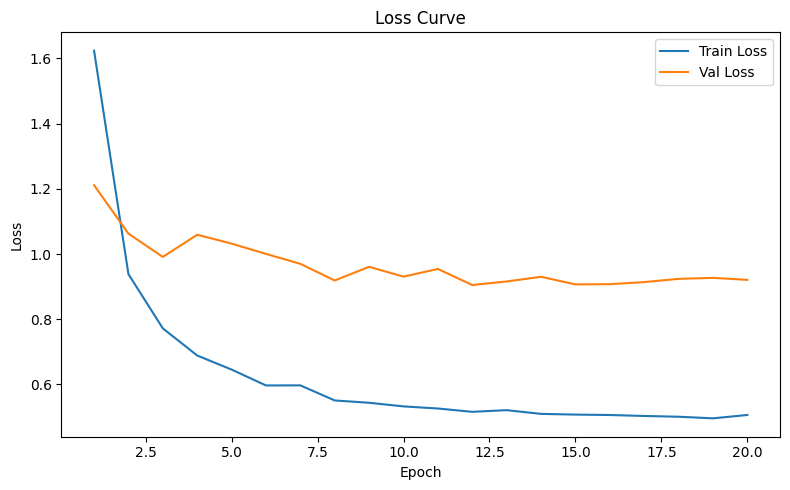

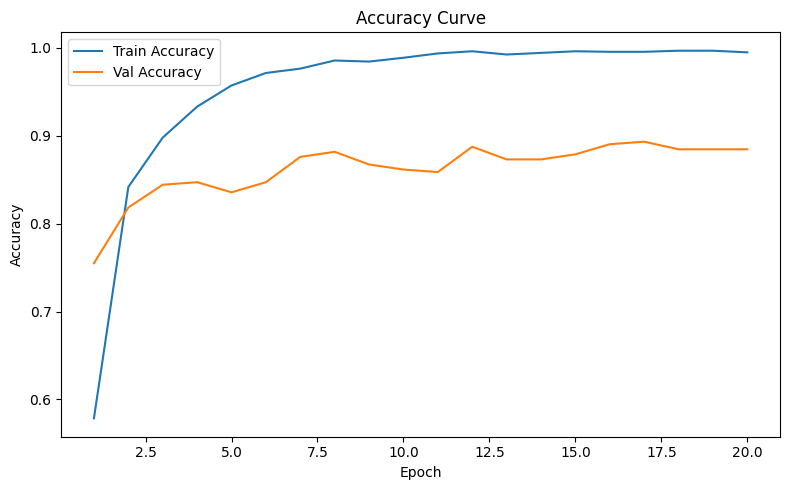


Test loss: 0.8612
{
  "accuracy": 0.8876080691642652,
  "macro_precision": 0.8208491895701198,
  "macro_recall": 0.8527821899269685,
  "macro_f1": 0.8326233427660323,
  "weighted_precision": 0.8938052712540012,
  "weighted_recall": 0.8876080691642652,
  "weighted_f1": 0.8899451314213659
}

Classification Report:

              precision    recall  f1-score   support

           0     0.8182    0.8182    0.8182        33
           1     0.7500    0.7317    0.7407        41
           2     0.8857    0.9118    0.8986        34
           3     0.9070    0.8864    0.8966        44
           4     0.9286    0.8667    0.8966        30
           5     0.9896    0.9694    0.9794        98
           6     0.8438    0.8438    0.8438        32
           7     0.2857    0.5000    0.3636         4
           8     0.8000    1.0000    0.8889         8
           9     1.0000    1.0000    1.0000        23

    accuracy                         0.8876       347
   macro avg     0.8208    0.8528 

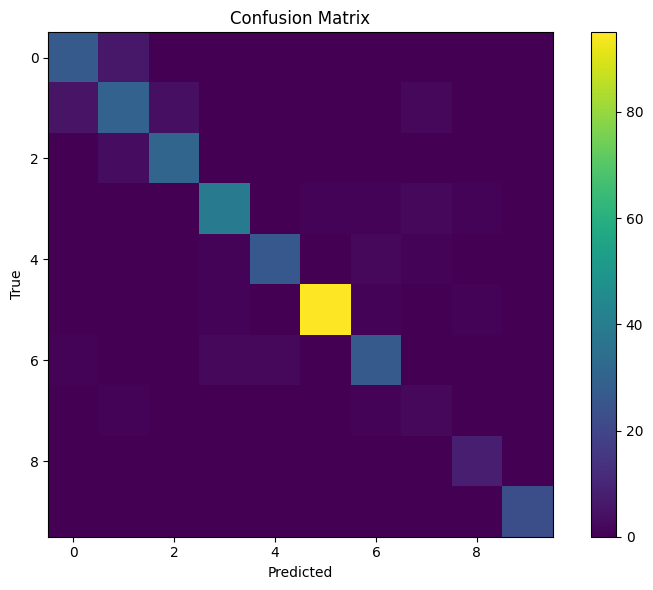


Saved summary:
                                            run_name  seed model_name  \
0  resnet18__adamw__weightedCE_True__labelsmooth_...    13   resnet18   

  optimizer_name  best_epoch  best_val_macro_f1  test_loss  accuracy  \
0          adamw          12            0.83928   0.861169  0.887608   

   macro_precision  macro_recall  macro_f1  weighted_precision  \
0         0.820849      0.852782  0.832623            0.893805   

   weighted_recall  weighted_f1  
0         0.887608     0.889945  

Saved files:
- accuracy_curve.png
- best_model.pth
- classification_report.txt
- config.json
- confusion_matrix.csv
- confusion_matrix.png
- loss_curve.png
- metrics_test.json
- run_summary.csv
- test_predictions.csv
- train_log.csv
- val_predictions.csv


In [78]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from tqdm import tqdm

warnings.filterwarnings("ignore")

# =========================
# CONFIG
# =========================
SEED = 13   # CHANGE ONLY THIS: 13 or 87

MODEL_NAME = "resnet18"
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 8
NUM_WORKERS = 0
IMAGE_SIZE = 224

USE_PRETRAINED = True
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
LABEL_SMOOTHING = 0.05

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"
if not SPLIT_CSV.exists():
    raise FileNotFoundError(f"Split CSV not found: {SPLIT_CSV}")

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("MODEL_NAME  :", MODEL_NAME)
print("SEED        :", SEED)

# =========================
# SEED + DEVICE
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# LOAD SPLIT
# =========================
split_df = pd.read_csv(SPLIT_CSV)

def normalize_path(path_str):
    path_str = str(path_str)
    p = Path(path_str)
    if p.exists():
        return str(p)

    if len(path_str) >= 3 and path_str[1:3] == ":\\":
        drive = path_str[0].lower()
        rest = path_str[3:].replace("\\", "/")
        wsl_path = f"/mnt/{drive}/{rest}"
        if Path(wsl_path).exists():
            return wsl_path

    if path_str.startswith("/mnt/") and len(path_str) > 7:
        drive = path_str[5]
        rest = path_str[7:].replace("/", "\\")
        win_path = f"{drive.upper()}:\\{rest}"
        if Path(win_path).exists():
            return win_path

    return path_str

split_df["filepath"] = split_df["filepath"].apply(normalize_path)

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df  = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain class counts:")
print(train_df["class_id"].value_counts().sort_index())

# =========================
# COMPUTE TRAIN MEAN / STD
# =========================
basic_transform_for_stats = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

class TempImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        img = self.transform(img)
        return img

temp_ds = TempImageDataset(train_df, basic_transform_for_stats)
temp_loader = DataLoader(
    temp_ds,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in tqdm(temp_loader, desc="Computing mean/std"):
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
    num_pixels += images.size(0) * images.size(2) * images.size(3)

train_mean = channel_sum / num_pixels
train_std = torch.sqrt(channel_sq_sum / num_pixels - train_mean ** 2)

print("\nTrain mean:", train_mean.tolist())
print("Train std :", train_std.tolist())

# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

# =========================
# DATASET / DATALOADER
# =========================
class GC10Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = int(row["class_id"]) - 1  # 1..10 -> 0..9
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, label, img_path

train_ds = GC10Dataset(train_df, train_transform)
val_ds   = GC10Dataset(val_df, eval_transform)
test_ds  = GC10Dataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("\nBatches:")
print("Train:", len(train_loader))
print("Val  :", len(val_loader))
print("Test :", len(test_loader))

# =========================
# MODEL
# =========================
def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)

# =========================
# LOSS / OPTIMIZER / SCHEDULER
# =========================
train_class_counts = train_df["class_id"].value_counts().sort_index()

class_weights = []
total_train = len(train_df)
for class_id in range(1, NUM_CLASSES + 1):
    count = int(train_class_counts[class_id])
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("\nClass weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# =========================
# METRICS
# =========================
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)
    return epoch_loss, metrics

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []
    all_paths = []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_logits.extend(outputs.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)

    pred_df = pd.DataFrame({
        "filepath": all_paths,
        "y_true": all_labels,
        "y_pred": all_preds,
    })

    probs_np = np.array(all_probs)
    logits_np = np.array(all_logits)

    for c in range(probs_np.shape[1]):
        pred_df[f"prob_class_{c}"] = probs_np[:, c]
        pred_df[f"logit_class_{c}"] = logits_np[:, c]

    return epoch_loss, metrics, pred_df

# =========================
# RUN DIR
# =========================
run_name = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)
RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "image_size": IMAGE_SIZE,
    "num_workers": NUM_WORKERS,
    "split_csv": str(SPLIT_CSV),
    "train_mean": train_mean.tolist(),
    "train_std": train_std.tolist(),
    "use_pretrained": USE_PRETRAINED,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_label_smoothing": USE_LABEL_SMOOTHING,
    "label_smoothing": LABEL_SMOOTHING,
}

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("\nRUN_DIR:", RUN_DIR)

# =========================
# TRAIN LOOP
# =========================
history = []
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_metrics, val_pred_df = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(model.state_dict(), RUN_DIR / "best_model.pth")
        val_pred_df.to_csv(RUN_DIR / "val_predictions.csv", index=False)
        print("Best model updated.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "train_log.csv", index=False)

print("\nBest epoch:", best_epoch)
print("Best val macro-F1:", best_val_f1)

# =========================
# PLOTS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

# =========================
# TEST
# =========================
best_model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)
best_model.load_state_dict(torch.load(RUN_DIR / "best_model.pth", map_location=DEVICE))

test_loss, test_metrics, test_pred_df = evaluate(best_model, test_loader, criterion, DEVICE)

print("\nTest loss:", round(test_loss, 4))
print(json.dumps(test_metrics, indent=2))

test_pred_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

with open(RUN_DIR / "metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
            "test_loss": float(test_loss),
            **{k: float(v) for k, v in test_metrics.items()}
        },
        f,
        indent=2
    )

# =========================
# REPORT + CONFUSION MATRIX
# =========================
y_true = test_pred_df["y_true"].values
y_pred = test_pred_df["y_pred"].values

report = classification_report(y_true, y_pred, digits=4, zero_division=0)
print("\nClassification Report:\n")
print(report)

with open(RUN_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm)
cm_df.to_csv(RUN_DIR / "confusion_matrix.csv", index=False)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# =========================
# SUMMARY
# =========================
summary_row = {
    "run_name": run_name,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "test_loss": test_loss,
    **test_metrics
}
summary_df = pd.DataFrame([summary_row])
summary_df.to_csv(RUN_DIR / "run_summary.csv", index=False)

print("\nSaved summary:")
print(summary_df)

print("\nSaved files:")
for f in sorted([p.name for p in RUN_DIR.iterdir()]):
    print("-", f)

BASE_DIR    : /mnt/e/CVPR
PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
SPLIT_CSV   : /mnt/e/CVPR/steel_failure_aware/data/processed/splits/gc10_split_seed_87.csv
MODEL_NAME  : resnet18
SEED        : 87
Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti

Split sizes:
Train: (1618, 14)
Val  : (347, 14)
Test : (347, 14)

Train class counts:
class_id
1     153
2     191
3     158
4     202
5     143
6     456
7     151
8      22
9      37
10    105
Name: count, dtype: int64


Computing mean/std: 100%|███████████████████████████████████████████████████████████████| 51/51 [00:26<00:00,  1.95it/s]



Train mean: [0.3348475992679596, 0.3348475992679596, 0.3348475992679596]
Train std : [0.15359212458133698, 0.15359212458133698, 0.15359212458133698]

Batches:
Train: 51
Val  : 11
Test : 11

Class weights: tensor([1.0575, 0.8471, 1.0241, 0.8010, 1.1315, 0.3548, 1.0715, 7.3545, 4.3730,
        1.5410], device='cuda:0')

RUN_DIR: /mnt/e/CVPR/steel_failure_aware/runs/closed_set/resnet18__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_87

Epoch 1/30


train_loss=1.5773 | val_loss=1.1264 | train_macro_f1=0.5363 | val_macro_f1=0.7476
Best model updated.

Epoch 2/30


train_loss=0.9390 | val_loss=1.0764 | train_macro_f1=0.7788 | val_macro_f1=0.7551
Best model updated.

Epoch 3/30


...

train_loss=0.4988 | val_loss=0.9316 | train_macro_f1=0.9963 | val_macro_f1=0.7874

Epoch 20/30


train_loss=0.4968 | val_loss=0.9023 | train_macro_f1=0.9952 | val_macro_f1=0.8202

Epoch 21/30


train_loss=0.4969 | val_loss=0.9278 | train_macro_f1=0.9963 | val_macro_f1=0.7914

Epoch 22/30


train_loss=0.4903 | val_loss=0.9271 | train_macro_f1=0.9956 | val_macro_f1=0.7913

Epoch 23/30


train_loss=0.4934 | val_loss=0.9217 | train_macro_f1=0.9952 | val_macro_f1=0.7942
Early stopping triggered at epoch 23.

Best epoch: 15
Best val macro-F1: 0.8437620744690417


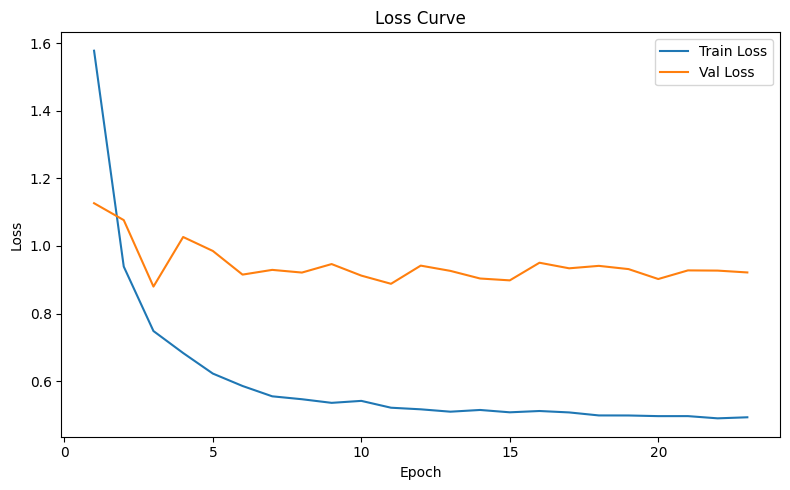

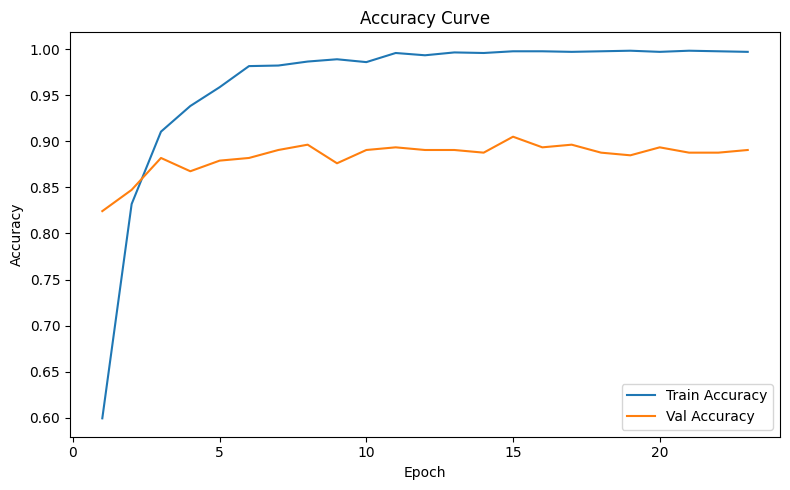


Test loss: 0.9167
{
  "accuracy": 0.8876080691642652,
  "macro_precision": 0.8360723154177243,
  "macro_recall": 0.8358894315888759,
  "macro_f1": 0.8330369086938868,
  "weighted_precision": 0.8926476192648838,
  "weighted_recall": 0.8876080691642652,
  "weighted_f1": 0.8873247534681392
}

Classification Report:

              precision    recall  f1-score   support

           0     0.7317    0.9091    0.8108        33
           1     0.8788    0.7073    0.7838        41
           2     0.9412    0.9412    0.9412        34
           3     0.9744    0.8837    0.9268        43
           4     0.8125    0.8667    0.8387        30
           5     0.9510    1.0000    0.9749        97
           6     0.8667    0.7879    0.8254        33
           7     0.5000    0.6000    0.5455         5
           8     0.7500    0.7500    0.7500         8
           9     0.9545    0.9130    0.9333        23

    accuracy                         0.8876       347
   macro avg     0.8361    0.8359 

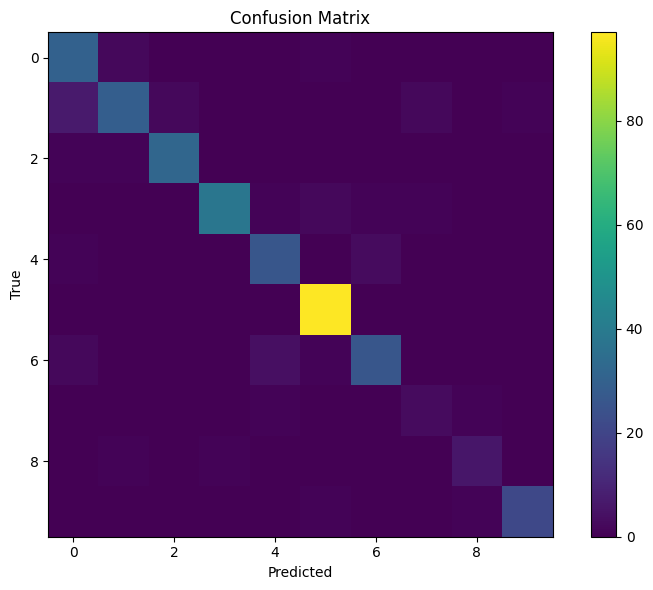


Saved summary:
                                            run_name  seed model_name  \
0  resnet18__adamw__weightedCE_True__labelsmooth_...    87   resnet18   

  optimizer_name  best_epoch  best_val_macro_f1  test_loss  accuracy  \
0          adamw          15           0.843762     0.9167  0.887608   

   macro_precision  macro_recall  macro_f1  weighted_precision  \
0         0.836072      0.835889  0.833037            0.892648   

   weighted_recall  weighted_f1  
0         0.887608     0.887325  

Saved files:
- accuracy_curve.png
- best_model.pth
- classification_report.txt
- config.json
- confusion_matrix.csv
- confusion_matrix.png
- loss_curve.png
- metrics_test.json
- run_summary.csv
- test_predictions.csv
- train_log.csv
- val_predictions.csv


In [79]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from tqdm import tqdm

warnings.filterwarnings("ignore")

# =========================
# CONFIG
# =========================
SEED = 87   # CHANGE ONLY THIS: 13 or 87

MODEL_NAME = "resnet18"
OPTIMIZER_NAME = "adamw"
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 8
NUM_WORKERS = 0
IMAGE_SIZE = 224

USE_PRETRAINED = True
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True
LABEL_SMOOTHING = 0.05

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find CVPR folder. Checked:\n" + "\n".join(str(p) for p in CANDIDATE_BASE_DIRS)
    )

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits"
RUNS_DIR = PROJECT_ROOT / "runs" / "closed_set"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_CSV = SPLITS_DIR / f"gc10_split_seed_{SEED}.csv"
if not SPLIT_CSV.exists():
    raise FileNotFoundError(f"Split CSV not found: {SPLIT_CSV}")

print("BASE_DIR    :", BASE_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_CSV   :", SPLIT_CSV)
print("MODEL_NAME  :", MODEL_NAME)
print("SEED        :", SEED)

# =========================
# SEED + DEVICE
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# LOAD SPLIT
# =========================
split_df = pd.read_csv(SPLIT_CSV)

def normalize_path(path_str):
    path_str = str(path_str)
    p = Path(path_str)
    if p.exists():
        return str(p)

    if len(path_str) >= 3 and path_str[1:3] == ":\\":
        drive = path_str[0].lower()
        rest = path_str[3:].replace("\\", "/")
        wsl_path = f"/mnt/{drive}/{rest}"
        if Path(wsl_path).exists():
            return wsl_path

    if path_str.startswith("/mnt/") and len(path_str) > 7:
        drive = path_str[5]
        rest = path_str[7:].replace("/", "\\")
        win_path = f"{drive.upper()}:\\{rest}"
        if Path(win_path).exists():
            return win_path

    return path_str

split_df["filepath"] = split_df["filepath"].apply(normalize_path)

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df  = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain class counts:")
print(train_df["class_id"].value_counts().sort_index())

# =========================
# COMPUTE TRAIN MEAN / STD
# =========================
basic_transform_for_stats = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

class TempImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        img = self.transform(img)
        return img

temp_ds = TempImageDataset(train_df, basic_transform_for_stats)
temp_loader = DataLoader(
    temp_ds,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in tqdm(temp_loader, desc="Computing mean/std"):
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
    num_pixels += images.size(0) * images.size(2) * images.size(3)

train_mean = channel_sum / num_pixels
train_std = torch.sqrt(channel_sq_sum / num_pixels - train_mean ** 2)

print("\nTrain mean:", train_mean.tolist())
print("Train std :", train_std.tolist())

# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

# =========================
# DATASET / DATALOADER
# =========================
class GC10Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = int(row["class_id"]) - 1  # 1..10 -> 0..9
        img = Image.open(img_path).convert("L")
        img = self.transform(img)
        return img, label, img_path

train_ds = GC10Dataset(train_df, train_transform)
val_ds   = GC10Dataset(val_df, eval_transform)
test_ds  = GC10Dataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("\nBatches:")
print("Train:", len(train_loader))
print("Val  :", len(val_loader))
print("Test :", len(test_loader))

# =========================
# MODEL
# =========================
def build_resnet18(num_classes=10, use_pretrained=True):
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.resnet18(weights=weights)
    except Exception:
        model = models.resnet18(pretrained=use_pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)

# =========================
# LOSS / OPTIMIZER / SCHEDULER
# =========================
train_class_counts = train_df["class_id"].value_counts().sort_index()

class_weights = []
total_train = len(train_df)
for class_id in range(1, NUM_CLASSES + 1):
    count = int(train_class_counts[class_id])
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("\nClass weights:", class_weights)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# =========================
# METRICS
# =========================
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)
    return epoch_loss, metrics

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []
    all_paths = []

    for images, labels, paths in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_logits.extend(outputs.cpu().numpy().tolist())
        all_paths.extend(list(paths))

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_classification_metrics(all_labels, all_preds)

    pred_df = pd.DataFrame({
        "filepath": all_paths,
        "y_true": all_labels,
        "y_pred": all_preds,
    })

    probs_np = np.array(all_probs)
    logits_np = np.array(all_logits)

    for c in range(probs_np.shape[1]):
        pred_df[f"prob_class_{c}"] = probs_np[:, c]
        pred_df[f"logit_class_{c}"] = logits_np[:, c]

    return epoch_loss, metrics, pred_df

# =========================
# RUN DIR
# =========================
run_name = (
    f"{MODEL_NAME}__{OPTIMIZER_NAME}"
    f"__weightedCE_{USE_WEIGHTED_LOSS}"
    f"__labelsmooth_{USE_LABEL_SMOOTHING}"
    f"__pretrained_{USE_PRETRAINED}"
    f"__seed_{SEED}"
)
RUN_DIR = RUNS_DIR / run_name
RUN_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "image_size": IMAGE_SIZE,
    "num_workers": NUM_WORKERS,
    "split_csv": str(SPLIT_CSV),
    "train_mean": train_mean.tolist(),
    "train_std": train_std.tolist(),
    "use_pretrained": USE_PRETRAINED,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_label_smoothing": USE_LABEL_SMOOTHING,
    "label_smoothing": LABEL_SMOOTHING,
}

with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("\nRUN_DIR:", RUN_DIR)

# =========================
# TRAIN LOOP
# =========================
history = []
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_metrics, val_pred_df = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(model.state_dict(), RUN_DIR / "best_model.pth")
        val_pred_df.to_csv(RUN_DIR / "val_predictions.csv", index=False)
        print("Best model updated.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "train_log.csv", index=False)

print("\nBest epoch:", best_epoch)
print("Best val macro-F1:", best_val_f1)

# =========================
# PLOTS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "accuracy_curve.png", dpi=200)
plt.show()

# =========================
# TEST
# =========================
best_model = build_resnet18(num_classes=NUM_CLASSES, use_pretrained=USE_PRETRAINED).to(DEVICE)
best_model.load_state_dict(torch.load(RUN_DIR / "best_model.pth", map_location=DEVICE))

test_loss, test_metrics, test_pred_df = evaluate(best_model, test_loader, criterion, DEVICE)

print("\nTest loss:", round(test_loss, 4))
print(json.dumps(test_metrics, indent=2))

test_pred_df.to_csv(RUN_DIR / "test_predictions.csv", index=False)

with open(RUN_DIR / "metrics_test.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
            "test_loss": float(test_loss),
            **{k: float(v) for k, v in test_metrics.items()}
        },
        f,
        indent=2
    )

# =========================
# REPORT + CONFUSION MATRIX
# =========================
y_true = test_pred_df["y_true"].values
y_pred = test_pred_df["y_pred"].values

report = classification_report(y_true, y_pred, digits=4, zero_division=0)
print("\nClassification Report:\n")
print(report)

with open(RUN_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm)
cm_df.to_csv(RUN_DIR / "confusion_matrix.csv", index=False)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# =========================
# SUMMARY
# =========================
summary_row = {
    "run_name": run_name,
    "seed": SEED,
    "model_name": MODEL_NAME,
    "optimizer_name": OPTIMIZER_NAME,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "test_loss": test_loss,
    **test_metrics
}
summary_df = pd.DataFrame([summary_row])
summary_df.to_csv(RUN_DIR / "run_summary.csv", index=False)

print("\nSaved summary:")
print(summary_df)

print("\nSaved files:")
for f in sorted([p.name for p in RUN_DIR.iterdir()]):
    print("-", f)

In [80]:
import torch

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_trainable_params(model))

Trainable parameters: 11181642


In [81]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/mnt/e/CVPR/steel_failure_aware")

csvs = list(PROJECT_ROOT.rglob("*.csv"))
for p in csvs:
    name = p.stem.lower()
    if "train" in name or "val" in name or "test" in name:
        try:
            df = pd.read_csv(p)
            print(p, "->", len(df))
        except:
            pass

/mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/test_bins_calibrated.csv -> 15
/mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/test_bins_uncalibrated.csv -> 15
/mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/test_predictions_calibrated.csv -> 347
/mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/val_bins_calibrated.csv -> 15
/mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/val_bins_uncalibrated.csv -> 15
/mnt/e/CVPR/steel_failure_aware/runs/calibration/mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_13/val_predictions_calibrate

In [82]:
from pathlib import Path

def count_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return sum(1 for p in Path(folder).rglob("*") if p.suffix.lower() in exts)

print("train:", count_images("/mnt/e/CVPR/steel_failure_aware/.../train"))
print("test :", count_images("/mnt/e/CVPR/steel_failure_aware/.../test"))

train: 0
test : 0
